In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

TARGET = 0.90
DAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]


In [2]:
def find_file(prefix):
    candidates = []
    for base in [Path('.'), Path('/mnt/data')]:
        candidates += sorted(base.glob(f"{prefix}*.csv"))
    if not candidates:
        raise FileNotFoundError(f"Could not find a CSV beginning with {prefix}")
    return candidates[0]

details_path = find_file('order_details')
timestamp_path = find_file('order_timestamp')
print('Details file:', details_path)
print('Timestamp file:', timestamp_path)

order_details = pd.read_csv(details_path)
order_timestamp = pd.read_csv(timestamp_path)
print('order_details:', order_details.shape)
print('order_timestamp:', order_timestamp.shape)
display(order_details.head(3))
display(order_timestamp.head(3))


Details file: order_details(3).csv
Timestamp file: order_timestamp(3).csv


order_details: (151803, 10)
order_timestamp: (151803, 4)


,order_id,created_date,order_city,order_offer_badge,batch,biker,vendor,district,order_fare,total_distance
0,568350652,2025-08-04,U,normal,0,"4,259,010.000",1346685,1432,1057143,"4,374.000"
1,568351152,2025-08-04,U,normal,0,"11,036,068.000",1190919,1428,971429,"4,914.200"
2,568351231,2025-08-04,K,normal,0,"8,549,168.000",668976,1512,657143,"1,747.700"


,order_id,start_time_slot,accept_time,arrived_pickup_at
0,568350652,2025-08-04 10:43,2025-08-04 10:43,2025-08-04 10:50
1,568351152,2025-08-04 10:21,2025-08-04 10:21,2025-08-04 10:27
2,568351231,2025-08-04 10:45,2025-08-04 10:46,2025-08-04 10:54


In [3]:
order_details['created_date'] = pd.to_datetime(order_details['created_date'], errors='coerce')
for c in ['start_time_slot','accept_time','arrived_pickup_at']:
    order_timestamp[c] = pd.to_datetime(order_timestamp[c], errors='coerce')

data = order_details.merge(order_timestamp, on='order_id', how='outer', indicator=True)



data['BATR_raw_min'] = (data['arrived_pickup_at'] - data['start_time_slot']).dt.total_seconds()/60

data['BATR_min'] = data['BATR_raw_min'].clip(lower=0)

data['accept_delay_min'] = (data['accept_time'] - data['start_time_slot']).dt.total_seconds()/60
data['arrival_after_accept_raw_min'] = (data['arrived_pickup_at'] - data['accept_time']).dt.total_seconds()/60
data['arrival_after_accept_min'] = data['arrival_after_accept_raw_min'].clip(lower=0)


data['BATR15'] = np.where(data['BATR_min'].notna(), (data['BATR_min'] <= 15).astype(int), np.nan)
data['Late15'] = np.where(data['BATR15'].notna(), 1-data['BATR15'], np.nan)


data['distance_clean'] = data['total_distance'].clip(lower=0)


slot = data['start_time_slot']
data['slot_date'] = slot.dt.floor('D')
data['slot_hour'] = slot.dt.hour
data['day_name'] = pd.Categorical(slot.dt.day_name(), categories=DAY_ORDER, ordered=True)
data['dow'] = slot.dt.dayofweek
data['week'] = slot.dt.to_period('W').astype(str)
data['month'] = slot.dt.to_period('M').astype(str)
data['is_weekend'] = slot.dt.dayofweek.isin([5,6])

def daypart(h):
    if pd.isna(h): return np.nan
    if 7 <= h < 11: return 'Morning'
    if 11 <= h < 15: return 'Lunch'
    if 15 <= h < 18: return 'Afternoon'
    if 18 <= h < 23: return 'Dinner'
    return 'Late night'
data['daypart'] = data['slot_hour'].map(daypart)


distance_edges = [-np.inf,500,1000,1500,2000,3000,4000,5000,7000,10000,np.inf]
distance_labels = ['<0.5 km','0.5–1 km','1–1.5 km','1.5–2 km','2–3 km','3–4 km','4–5 km','5–7 km','7–10 km','10+ km']
data['distance_bin'] = pd.cut(data['distance_clean'], distance_edges, labels=distance_labels, right=False)


valid_q = data['order_fare'].notna()
data.loc[valid_q, 'fare_decile'] = pd.qcut(data.loc[valid_q,'order_fare'], 10, labels=[f'D{i}' for i in range(1,11)], duplicates='drop').astype(str)
valid_d = data['distance_clean'].notna()
data.loc[valid_d, 'distance_decile'] = pd.qcut(data.loc[valid_d,'distance_clean'], 10, labels=[f'D{i}' for i in range(1,11)], duplicates='drop').astype(str)
DECILE_ORDER = [f'D{i}' for i in range(1,11)]
data['fare_decile'] = pd.Categorical(data['fare_decile'], categories=DECILE_ORDER, ordered=True)
data['distance_decile'] = pd.Categorical(data['distance_decile'], categories=DECILE_ORDER, ordered=True)


print('Merged shape:', data.shape)
print('Date range:', data['start_time_slot'].min(), '→', data['start_time_slot'].max())


Merged shape: (151803, 33)
Date range: 2025-08-02 07:51:00 → 2025-11-01 00:01:00


In [4]:
quality = pd.Series({
    'Rows': len(data),
    'Unique order_id': data['order_id'].nunique(dropna=True),
    'Exact duplicate rows': data.drop(columns=['_merge']).duplicated().sum(),
    'Duplicated order_id rows': data['order_id'].duplicated().sum(),
    'Missing start_time_slot': data['start_time_slot'].isna().sum(),
    'Missing accept_time': data['accept_time'].isna().sum(),
    'Missing arrived_pickup_at': data['arrived_pickup_at'].isna().sum(),
    'Missing KPI BATR': data['BATR_min'].isna().sum(),
    'Negative raw BATR': (data['BATR_raw_min'] < 0).sum(),
    'Negative arrival-after-accept (set to 0)': (data['arrival_after_accept_raw_min'] < 0).sum(),
    'Negative acceptance delay': (data['accept_delay_min'] < 0).sum(),
    'Negative total_distance': (data['total_distance'] < 0).sum(),
})
display(quality.to_frame('Count'))
print('\nMerge coverage:')
display(data['_merge'].value_counts(dropna=False).to_frame('orders'))


,Count
Rows,151803
Unique order_id,151803
Exact duplicate rows,0
Duplicated order_id rows,0
Missing start_time_slot,221
Missing accept_time,224
Missing arrived_pickup_at,0
Missing KPI BATR,221
Negative raw BATR,23805
Negative arrival-after-accept (set to 0),23805



Merge coverage:


,orders
_merge,
both,151803
left_only,0
right_only,0


In [5]:
summary_cols = ['BATR_raw_min','BATR_min','accept_delay_min','arrival_after_accept_raw_min','arrival_after_accept_min','order_fare','total_distance']
display(data[summary_cols].describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99]).T)


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
BATR_raw_min,"151,582.000",9.532,202.378,"-69,761.000",-4.000,-3.000,-2.000,1.000,6.000,15.000,23.000,30.000,51.000,"23,059.000"
BATR_min,"151,582.000",10.357,93.987,0.000,0.000,0.000,0.000,1.000,6.000,15.000,23.000,30.000,51.000,"23,059.000"
accept_delay_min,"151,579.000",4.459,9.397,0.000,0.000,0.000,0.000,0.000,0.000,8.000,13.000,17.000,33.000,903.000
arrival_after_accept_raw_min,"151,579.000",5.072,202.104,"-69,772.000",-4.000,-3.000,-2.000,1.000,4.000,7.000,11.000,16.000,33.000,"23,058.000"
arrival_after_accept_min,"151,579.000",5.897,93.377,0.000,0.000,0.000,0.000,1.000,4.000,7.000,11.000,16.000,33.000,"23,058.000"
order_fare,"151,803.000","1,052,254.100","528,479.471","157,143.000","442,857.000","485,714.000","528,571.000","657,143.000","914,286.000","1,314,286.000","1,742,857.000","2,085,714.000","2,871,429.000","8,328,571.000"
total_distance,"151,803.000","3,091.800","2,363.868",-0.200,294.600,646.900,921.910,"1,517.000","2,473.600","3,897.250","6,004.440","7,966.080","11,876.202","32,357.200"


In [6]:
VALID = data[data['BATR15'].notna()].copy()
OVERALL = VALID['BATR15'].mean()
TOTAL_LATE = VALID['Late15'].sum()

def q90(s): return s.quantile(.90)
def q95(s): return s.quantile(.95)

def wilson_ci(successes, n, z=1.96):
    successes = np.asarray(successes, dtype=float)
    n = np.asarray(n, dtype=float)
    p = np.divide(successes, n, out=np.full_like(successes, np.nan), where=n>0)
    denom = 1 + z*z/n
    center = (p + z*z/(2*n))/denom
    margin = z*np.sqrt((p*(1-p)/n) + z*z/(4*n*n))/denom
    return center-margin, center+margin

def performance_table(group_cols, frame=VALID, min_orders=1):
    if isinstance(group_cols, str): group_cols=[group_cols]
    r = (frame.groupby(group_cols, dropna=False, observed=True)
         .agg(Orders=('order_id','size'),
              Successes=('BATR15','sum'),
              BATR15_Rate=('BATR15','mean'),
              Late_Orders=('Late15','sum'),
              Median_BATR=('BATR_min','median'),
              P90_BATR=('BATR_min',q90),
              P95_BATR=('BATR_min',q95),
              Avg_Accept_Delay=('accept_delay_min','mean'),
              Avg_Arrival_After_Accept=('arrival_after_accept_min','mean'))
         .reset_index())
    lo, hi = wilson_ci(r['Successes'], r['Orders'])
    r['CI95_Low'] = 100*lo; r['CI95_High'] = 100*hi
    r['BATR15_%'] = 100*r['BATR15_Rate']
    r['Gap_vs_Overall_pp'] = 100*(r['BATR15_Rate'] - OVERALL)
    r['Late_Share_%'] = 100*r['Late_Orders']/TOTAL_LATE
    r['Late_Rate_%'] = 100*(1-r['BATR15_Rate'])
    return r[r['Orders'] >= min_orders].copy()

def show_perf(group_cols, min_orders=1, sort='BATR15_%', ascending=True, n=30):
    r=performance_table(group_cols, min_orders=min_orders).sort_values(sort, ascending=ascending)
    display(r.head(n))
    return r

print(f'Valid KPI orders: {len(VALID):,}')
print(f'Overall BATR≤15: {OVERALL*100:.2f}% vs target >90%')
print(f'Gap to 90% target: {(OVERALL-TARGET)*100:.2f} pp')


Valid KPI orders: 151,582
Overall BATR≤15: 77.45% vs target >90%
Gap to 90% target: -12.55 pp


In [7]:
overall_summary = pd.DataFrame({
    'Metric':['Orders with valid BATR','BATR≤15 rate','Target','Gap to target','Median BATR','P75 BATR','P90 BATR','P95 BATR','Late orders'],
    'Value':[f"{len(VALID):,}",f"{OVERALL*100:.2f}%",'>90%',f"{(OVERALL-TARGET)*100:.2f} pp",
             f"{VALID.BATR_min.median():.1f} min",f"{VALID.BATR_min.quantile(.75):.1f} min",f"{VALID.BATR_min.quantile(.90):.1f} min",f"{VALID.BATR_min.quantile(.95):.1f} min",f"{int(TOTAL_LATE):,}"]
})
display(overall_summary)


,Metric,Value
0,Orders with valid BATR,"151,582"
1,BATR≤15 rate,77.45%
2,Target,>90%
3,Gap to target,-12.55 pp
4,Median BATR,6.0 min
5,P75 BATR,15.0 min
6,P90 BATR,23.0 min
7,P95 BATR,30.0 min
8,Late orders,"34,178"


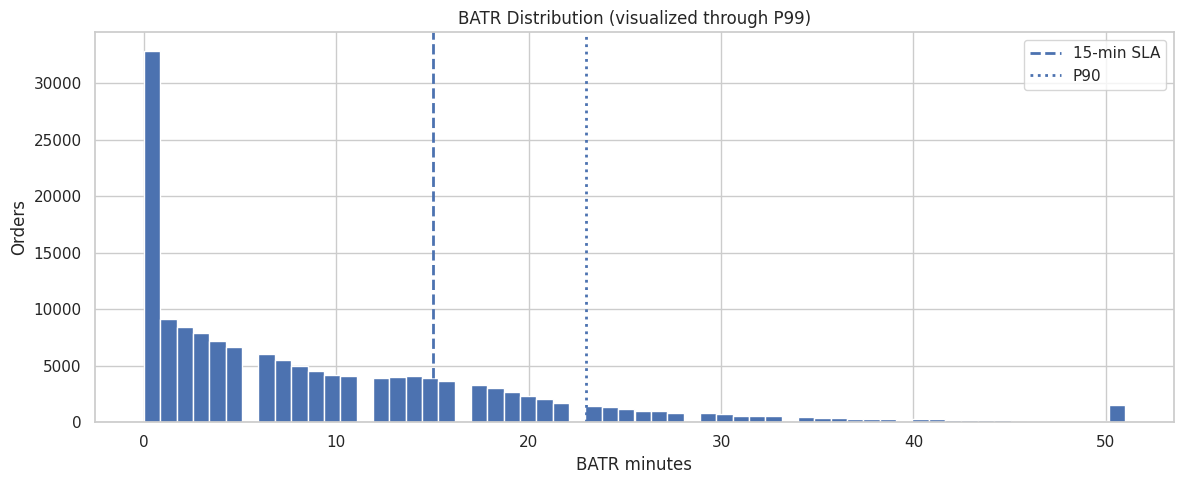

In [8]:
cap = VALID['BATR_min'].quantile(.99)
fig, ax = plt.subplots(figsize=(12,5))
ax.hist(VALID['BATR_min'].clip(upper=cap), bins=60)
ax.axvline(15, linestyle='--', linewidth=2, label='15-min SLA')
ax.axvline(VALID['BATR_min'].quantile(.90), linestyle=':', linewidth=2, label='P90')
ax.set(title='BATR Distribution (visualized through P99)', xlabel='BATR minutes', ylabel='Orders')
ax.legend(); plt.tight_layout(); plt.show()


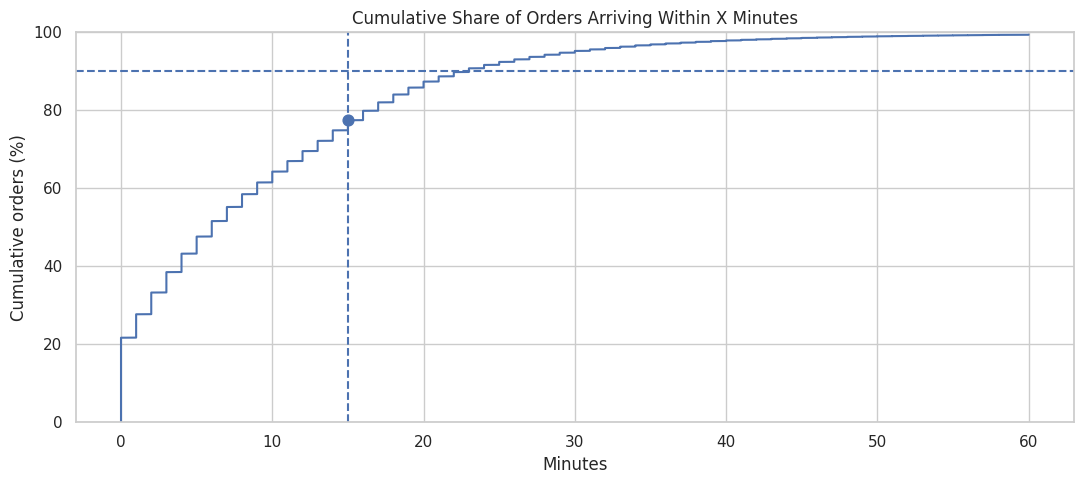

In [9]:
s = np.sort(VALID['BATR_min'].values)
y = np.arange(1,len(s)+1)/len(s)
plt.figure(figsize=(11,5))
plt.plot(s[s<=60], y[s<=60]*100)
plt.axvline(15, linestyle='--'); plt.axhline(90, linestyle='--')
plt.scatter([15],[OVERALL*100], s=60)
plt.title('Cumulative Share of Orders Arriving Within X Minutes')
plt.xlabel('Minutes'); plt.ylabel('Cumulative orders (%)'); plt.ylim(0,100)
plt.tight_layout(); plt.show()


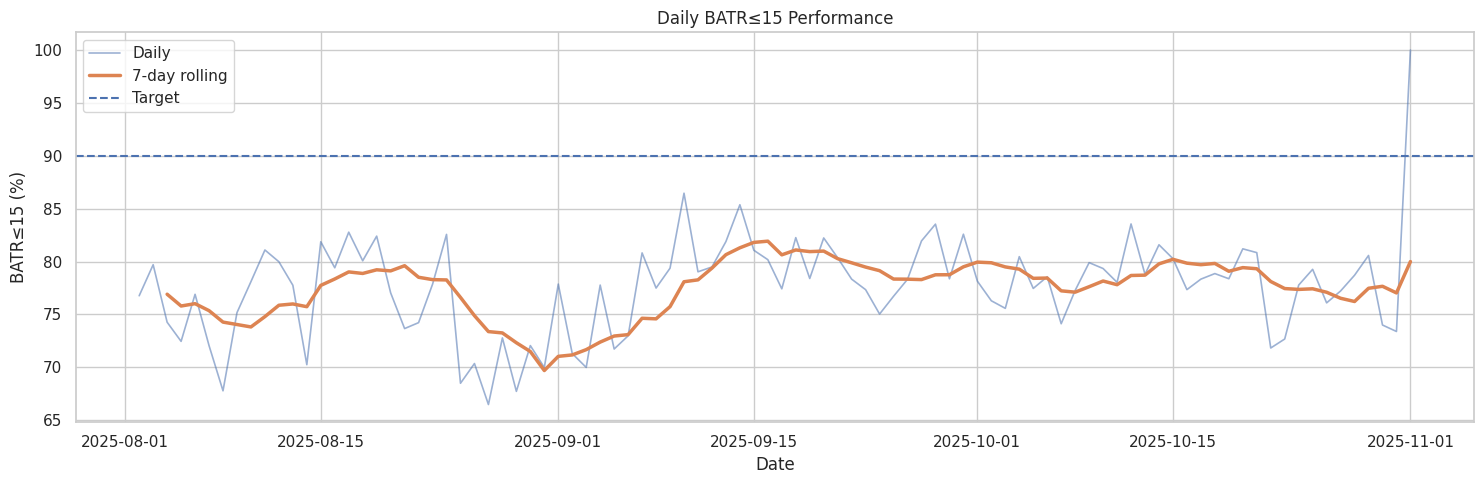

,slot_date,Orders,BATR15_%,P90_BATR,Late_Orders,Late_Share_%
25,2025-08-27,1468,66.485,28.000,492.000,1.440
27,2025-08-29,1599,67.730,26.000,516.000,1.510
6,2025-08-08,1434,67.782,29.000,462.000,1.352
23,2025-08-25,1476,68.496,27.000,465.000,1.361
29,2025-08-31,1526,69.987,27.000,458.000,1.340
32,2025-09-03,1413,69.993,27.000,424.000,1.241
12,2025-08-14,1190,70.252,26.000,354.000,1.036
24,2025-08-26,1390,70.360,28.000,412.000,1.205
31,2025-09-02,1582,71.302,26.000,454.000,1.328
34,2025-09-05,1822,71.734,25.000,515.000,1.507


In [10]:
daily = performance_table('slot_date')
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(daily['slot_date'], daily['BATR15_%'], linewidth=1.2, alpha=.55, label='Daily')
ax.plot(daily['slot_date'], daily['BATR15_%'].rolling(7, min_periods=3).mean(), linewidth=2.5, label='7-day rolling')
ax.axhline(90, linestyle='--', label='Target')
ax.set(title='Daily BATR≤15 Performance', ylabel='BATR≤15 (%)', xlabel='Date')
ax.legend(); plt.tight_layout(); plt.show()

display(daily.nsmallest(10,'BATR15_%')[['slot_date','Orders','BATR15_%','P90_BATR','Late_Orders','Late_Share_%']])


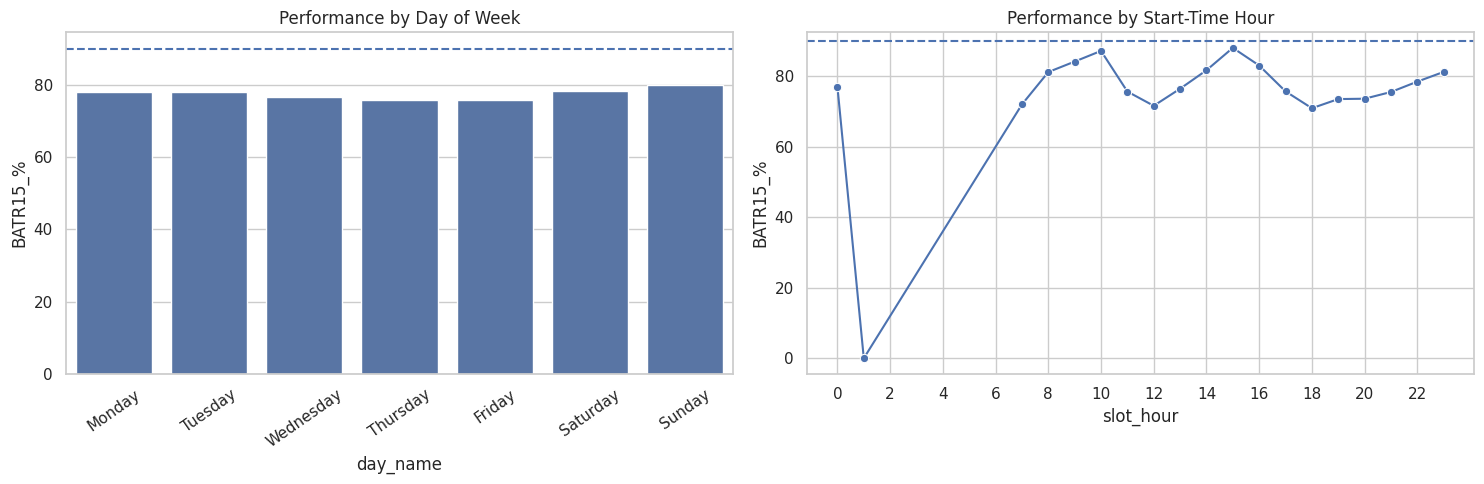

,slot_hour,Orders,BATR15_%,P90_BATR,Late_Orders,Late_Share_%,Avg_Accept_Delay,Avg_Arrival_After_Accept
15,20.000,15555,73.668,24.000,"4,096.000",11.984,5.144,5.674
8,13.000,16965,76.505,23.000,"3,986.000",11.662,4.783,5.786
16,21.000,15285,75.577,23.000,"3,733.000",10.922,4.952,5.188
7,12.000,12742,71.661,25.000,"3,611.000",10.565,5.567,8.106
14,19.000,12151,73.566,25.000,"3,212.000",9.398,4.915,6.205
9,14.000,16104,81.744,21.000,"2,940.000",8.602,3.936,6.050
17,22.000,11831,78.523,22.000,"2,541.000",7.435,4.416,4.717
13,18.000,8243,70.969,26.000,"2,393.000",7.002,5.076,9.199
6,11.000,7124,75.702,24.000,"1,731.000",5.065,4.404,6.119
12,17.000,5919,75.756,24.000,"1,435.000",4.199,4.401,5.921


In [11]:
weekday = performance_table('day_name').sort_values('day_name')
hour = performance_table('slot_hour').sort_values('slot_hour')
fig, axes = plt.subplots(1,2,figsize=(15,5))
sns.barplot(data=weekday, x='day_name', y='BATR15_%', ax=axes[0], color='C0')
axes[0].axhline(90, linestyle='--'); axes[0].tick_params(axis='x', rotation=35); axes[0].set_title('Performance by Day of Week')
sns.lineplot(data=hour, x='slot_hour', y='BATR15_%', marker='o', ax=axes[1], color='C0')
axes[1].axhline(90, linestyle='--'); axes[1].set_title('Performance by Start-Time Hour'); axes[1].set_xticks(range(0,24,2))
plt.tight_layout(); plt.show()
display(hour.sort_values('Late_Orders', ascending=False).head(10)[['slot_hour','Orders','BATR15_%','P90_BATR','Late_Orders','Late_Share_%','Avg_Accept_Delay','Avg_Arrival_After_Accept']])


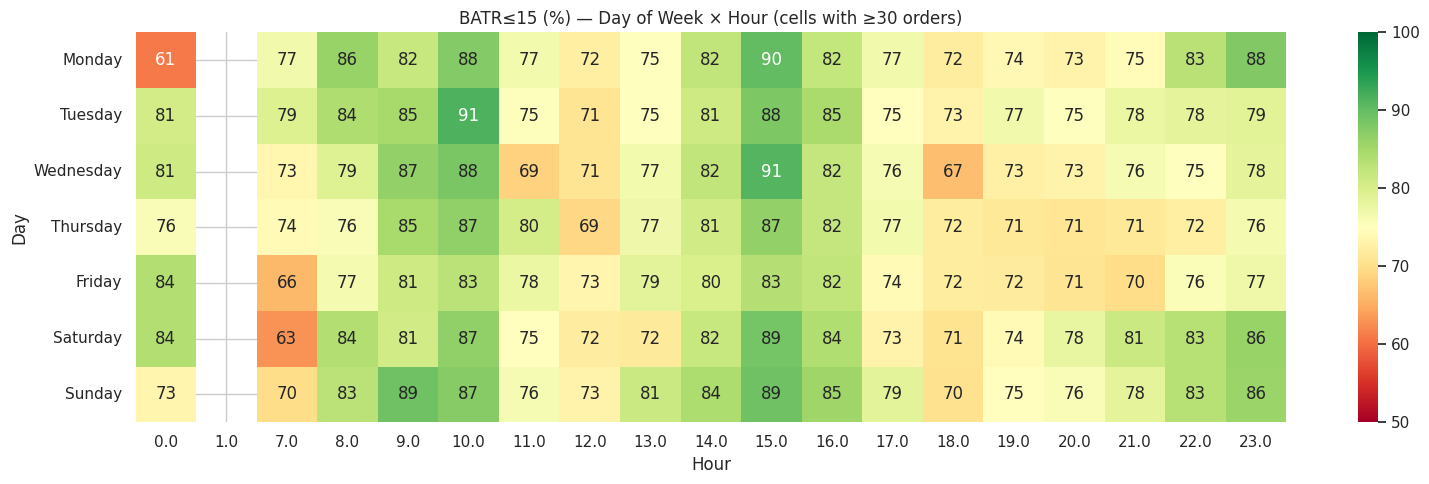

In [12]:
wh = (VALID.groupby(['day_name','slot_hour'], observed=True)
      .agg(Orders=('order_id','size'), Rate=('BATR15','mean')).reset_index())
wh.loc[wh['Orders']<30,'Rate']=np.nan
mat = wh.pivot(index='day_name', columns='slot_hour', values='Rate')*100
plt.figure(figsize=(16,5))
sns.heatmap(mat, annot=True, fmt='.0f', vmin=50, vmax=100, cmap='RdYlGn')
plt.title('BATR≤15 (%) — Day of Week × Hour (cells with ≥30 orders)')
plt.xlabel('Hour'); plt.ylabel('Day'); plt.tight_layout(); plt.show()


,order_city,Orders,BATR15_%,CI95_Low,CI95_High,Median_BATR,P90_BATR,Late_Orders,Late_Share_%,Avg_Accept_Delay,Avg_Arrival_After_Accept
1,K,78888,72.425,72.113,72.736,8.000,25.000,"21,753.000",63.646,5.229,6.862
2,U,51368,79.834,79.485,80.179,6.000,21.000,"10,359.000",30.309,4.363,5.305
0,B,21326,90.312,89.908,90.702,2.000,15.000,"2,066.000",6.045,1.845,3.754


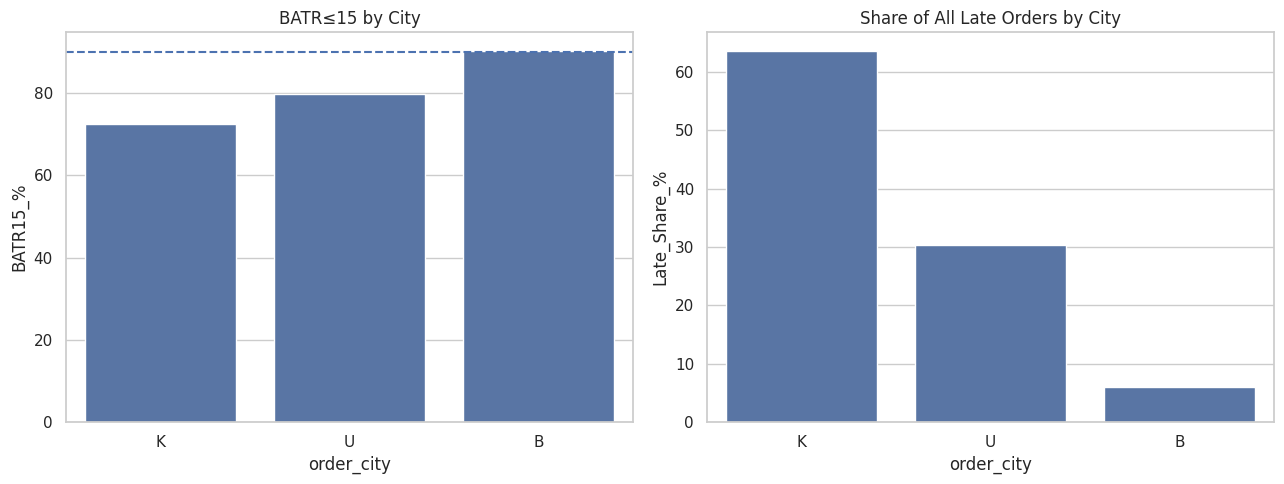

In [13]:
city = performance_table('order_city').sort_values('BATR15_%')
display(city[['order_city','Orders','BATR15_%','CI95_Low','CI95_High','Median_BATR','P90_BATR','Late_Orders','Late_Share_%','Avg_Accept_Delay','Avg_Arrival_After_Accept']])

fig, axes = plt.subplots(1,2,figsize=(13,5))
sns.barplot(data=city, x='order_city', y='BATR15_%', ax=axes[0], color='C0')
axes[0].axhline(90, linestyle='--'); axes[0].set_title('BATR≤15 by City')
sns.barplot(data=city, x='order_city', y='Late_Share_%', ax=axes[1], color='C0')
axes[1].set_title('Share of All Late Orders by City')
plt.tight_layout(); plt.show()


In [14]:
district = performance_table(['order_city','district'])
stable_district = district[district['Orders']>=100].copy()
print('Worst stable districts by SLA rate:')
display(stable_district.nsmallest(15,'BATR15_%')[['order_city','district','Orders','BATR15_%','P90_BATR','Late_Orders','Late_Share_%','Avg_Accept_Delay','Avg_Arrival_After_Accept']])
print('\nLargest contributors to total late orders:')
display(stable_district.nlargest(15,'Late_Orders')[['order_city','district','Orders','BATR15_%','P90_BATR','Late_Orders','Late_Share_%']])


Worst stable districts by SLA rate:


,order_city,district,Orders,BATR15_%,P90_BATR,Late_Orders,Late_Share_%,Avg_Accept_Delay,Avg_Arrival_After_Accept
16,K,1520,222,61.712,25.000,85.000,0.249,5.887,7.221
17,K,1528,7115,66.381,27.000,"2,392.000",6.999,6.968,6.127
10,K,1484,5410,67.652,27.000,"1,750.000",5.120,6.710,6.030
15,K,1512,10864,69.008,26.000,"3,367.000",9.851,6.287,5.764
23,U,1400,4162,69.822,29.000,"1,256.000",3.675,7.973,6.299
13,K,1496,1327,69.857,27.000,400.000,1.170,6.719,5.716
9,K,1480,26893,70.186,25.000,"8,018.000",23.460,6.002,6.718
8,K,1476,3259,71.402,24.000,932.000,2.727,6.056,12.998
18,K,4176,4216,71.845,33.500,"1,187.000",3.473,3.119,9.898
27,U,1416,3149,74.151,24.000,814.000,2.382,5.290,6.130



Largest contributors to total late orders:


,order_city,district,Orders,BATR15_%,P90_BATR,Late_Orders,Late_Share_%
9,K,1480,26893,70.186,25.000,"8,018.000",23.460
15,K,1512,10864,69.008,26.000,"3,367.000",9.851
17,K,1528,7115,66.381,27.000,"2,392.000",6.999
31,U,1432,13113,81.896,20.000,"2,374.000",6.946
30,U,1428,8576,77.320,22.000,"1,945.000",5.691
10,K,1484,5410,67.652,27.000,"1,750.000",5.120
14,K,1508,8887,80.770,20.000,"1,709.000",5.000
28,U,1420,12031,85.995,18.000,"1,685.000",4.930
23,U,1400,4162,69.822,29.000,"1,256.000",3.675
18,K,4176,4216,71.845,33.500,"1,187.000",3.473


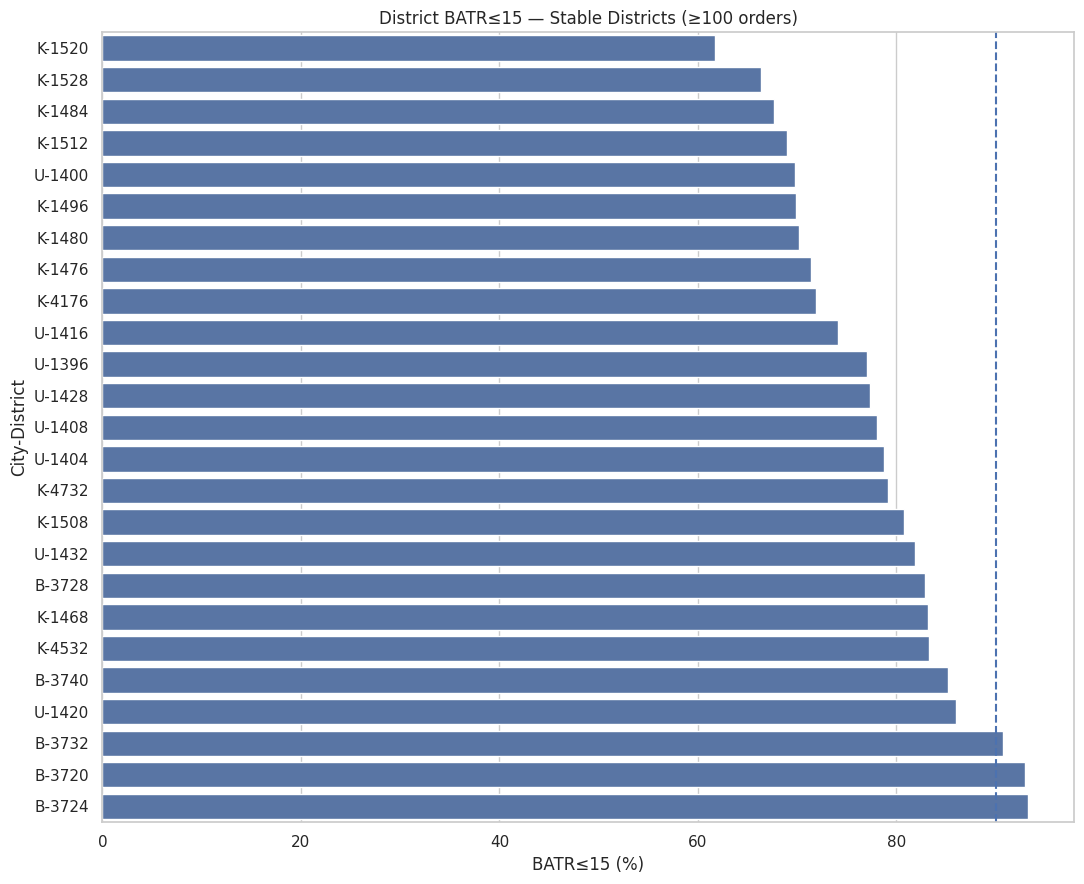

In [15]:
plot_d = stable_district.sort_values('BATR15_%')
plot_d['label'] = plot_d['order_city'].astype(str)+'-'+plot_d['district'].astype(str)
fig, ax=plt.subplots(figsize=(11,9))
sns.barplot(data=plot_d, y='label', x='BATR15_%', ax=ax, color='C0')
ax.axvline(90, linestyle='--'); ax.set_title('District BATR≤15 — Stable Districts (≥100 orders)'); ax.set_xlabel('BATR≤15 (%)'); ax.set_ylabel('City-District')
plt.tight_layout(); plt.show()


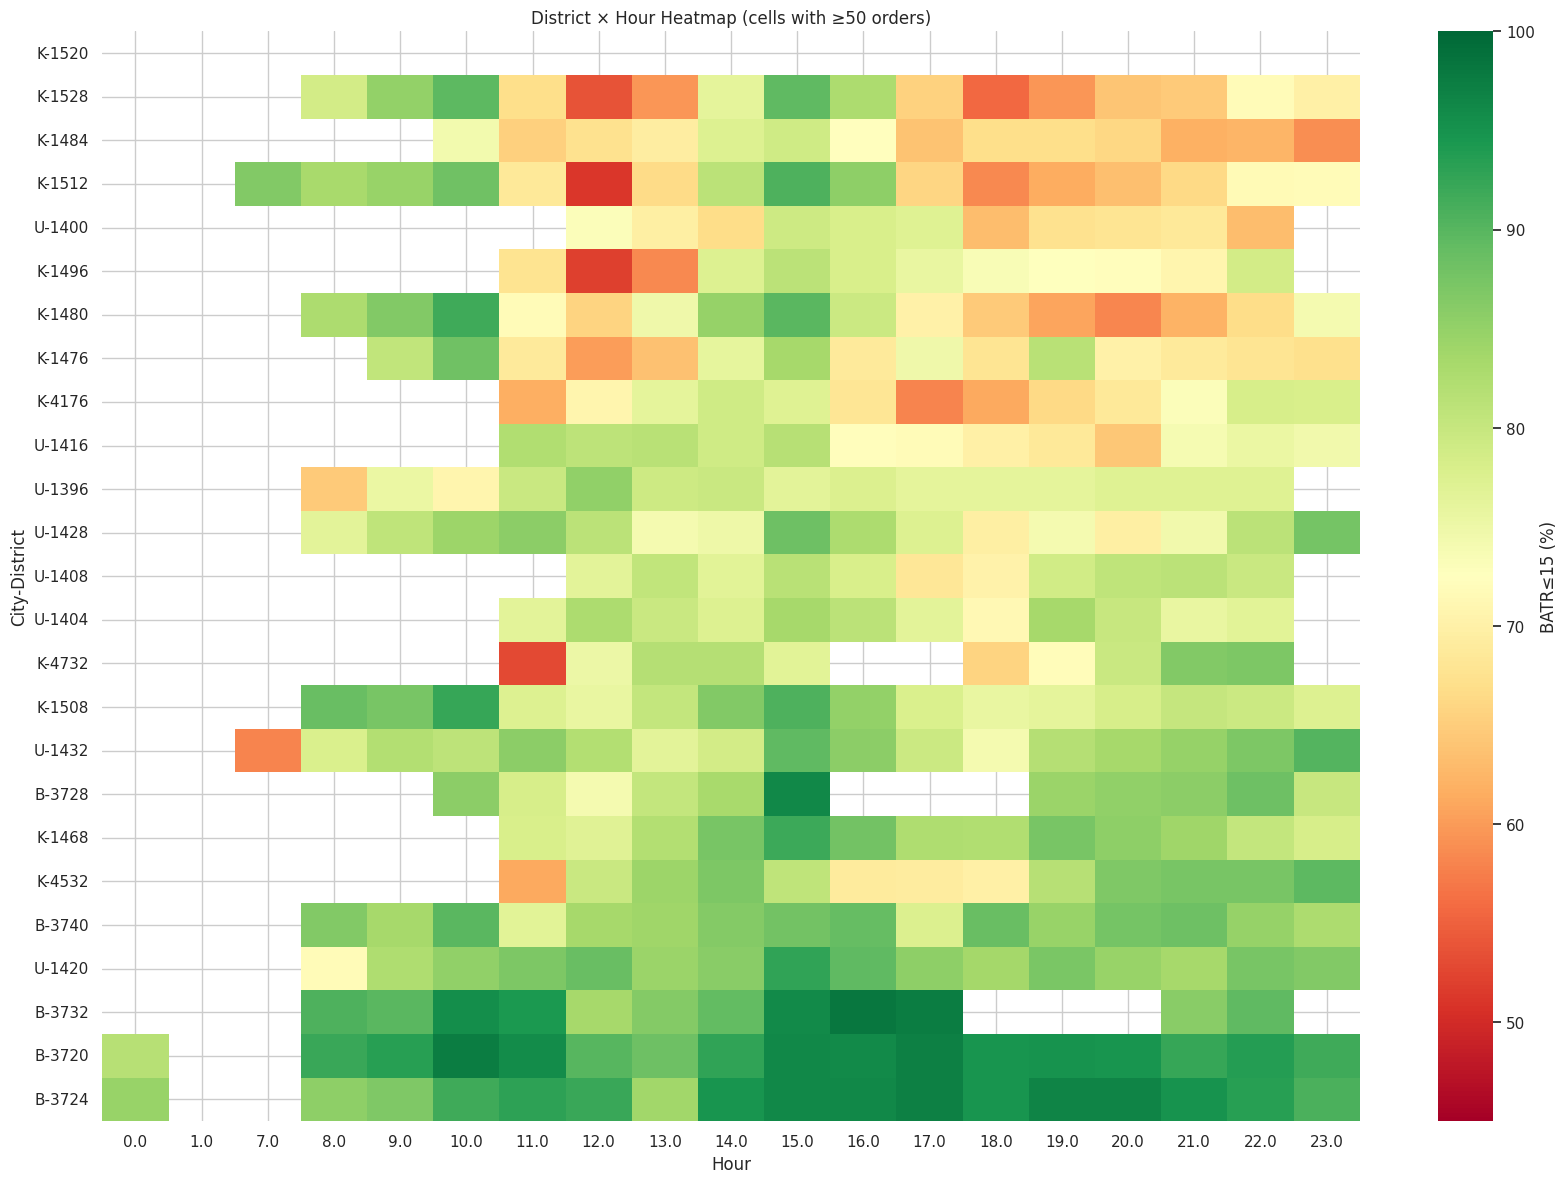

In [16]:
dh = (VALID.groupby(['order_city','district','slot_hour'], observed=True)
      .agg(Orders=('order_id','size'), Rate=('BATR15','mean'), P90=('BATR_min', q90), Late=('Late15','sum')).reset_index())
dh['label'] = dh['order_city'].astype(str)+'-'+dh['district'].astype(str)
dh.loc[dh['Orders']<50,'Rate']=np.nan
mat = dh.pivot(index='label',columns='slot_hour',values='Rate')*100

order_labels = stable_district.sort_values('BATR15_%').assign(label=lambda q:q.order_city.astype(str)+'-'+q.district.astype(str))['label']
mat = mat.reindex([v for v in order_labels if v in mat.index])
plt.figure(figsize=(17,12))
sns.heatmap(mat, vmin=45, vmax=100, cmap='RdYlGn', cbar_kws={'label':'BATR≤15 (%)'})
plt.title('District × Hour Heatmap (cells with ≥50 orders)')
plt.xlabel('Hour'); plt.ylabel('City-District'); plt.tight_layout(); plt.show()


In [17]:
district_date_hour = (VALID.groupby(['slot_date','order_city','district','slot_hour'], observed=True)
    .agg(Orders=('order_id','size'), BATR15_Rate=('BATR15','mean'), Median_BATR=('BATR_min','median'), P90_BATR=('BATR_min',q90), Late_Orders=('Late15','sum'),
         Avg_Accept=('accept_delay_min','mean'), Avg_Arrival=('arrival_after_accept_min','mean'))
    .reset_index())
district_date_hour['BATR15_%']=100*district_date_hour['BATR15_Rate']
print('Worst district-date-hour cells with at least 20 orders:')
display(district_date_hour[district_date_hour.Orders>=20].sort_values(['BATR15_%','Orders'],ascending=[True,False]).head(40))


Worst district-date-hour cells with at least 20 orders:


,slot_date,order_city,district,slot_hour,Orders,BATR15_Rate,Median_BATR,P90_BATR,Late_Orders,Avg_Accept,Avg_Arrival,BATR15_%
16870,2025-09-26,K,1480,20.000,25,0.160,19.000,28.200,21.000,12.800,6.480,16.000
10323,2025-09-05,K,1480,20.000,31,0.194,21.000,53.000,25.000,18.290,7.645,19.355
1876,2025-08-08,K,1480,21.000,37,0.216,20.000,34.200,29.000,14.811,6.486,21.622
16586,2025-09-25,K,1512,12.000,22,0.227,18.000,24.900,17.000,11.500,7.091,22.727
1875,2025-08-08,K,1480,20.000,33,0.242,21.000,35.800,25.000,13.394,7.939,24.242
8451,2025-08-30,K,1480,19.000,23,0.261,22.000,32.000,17.000,14.522,7.261,26.087
19520,2025-10-04,K,1512,12.000,22,0.273,21.500,48.600,16.000,14.773,12.318,27.273
23398,2025-10-16,K,1480,20.000,32,0.281,23.500,41.000,23.000,15.406,9.219,28.125
28036,2025-10-30,K,1480,19.000,32,0.281,19.500,48.300,23.000,15.594,9.781,28.125
27030,2025-10-27,K,1480,19.000,40,0.300,17.000,30.100,28.000,11.825,7.125,30.000


In [18]:
badge = performance_table('order_offer_badge').sort_values('BATR15_%')
batch = performance_table('batch').sort_values('BATR15_%')
badge_batch = performance_table(['order_offer_badge','batch']).sort_values('BATR15_%')
print('Offer badge:'); display(badge[['order_offer_badge','Orders','BATR15_%','P90_BATR','Late_Orders','Late_Share_%','Avg_Accept_Delay','Avg_Arrival_After_Accept']])
print('Batch:'); display(batch[['batch','Orders','BATR15_%','P90_BATR','Late_Orders','Late_Share_%','Avg_Accept_Delay','Avg_Arrival_After_Accept']])
print('Badge × Batch:'); display(badge_batch[['order_offer_badge','batch','Orders','BATR15_%','P90_BATR','Late_Orders','Late_Share_%','Avg_Accept_Delay','Avg_Arrival_After_Accept']])


Offer badge:


,order_offer_badge,Orders,BATR15_%,P90_BATR,Late_Orders,Late_Share_%,Avg_Accept_Delay,Avg_Arrival_After_Accept
0,delayed,24770,17.558,38.000,"20,421.000",59.749,16.674,8.184
1,normal,126776,89.149,16.000,"13,757.000",40.251,2.074,5.452
2,NaN,36,100.000,0.000,0.000,0.000,0.000,0.389


Batch:


,batch,Orders,BATR15_%,P90_BATR,Late_Orders,Late_Share_%,Avg_Accept_Delay,Avg_Arrival_After_Accept
0,0,133271,77.174,23.000,"30,420.000",89.005,4.590,5.937
1,1,18311,79.477,23.000,"3,758.000",10.995,3.510,5.609


Badge × Batch:


,order_offer_badge,batch,Orders,BATR15_%,P90_BATR,Late_Orders,Late_Share_%,Avg_Accept_Delay,Avg_Arrival_After_Accept
1,delayed,1,862,2.552,43.000,840.000,2.458,21.878,7.466
0,delayed,0,23908,18.099,38.000,"19,581.000",57.291,16.486,8.210
3,normal,1,17447,83.275,20.000,"2,918.000",8.538,2.603,5.518
2,normal,0,109329,90.086,15.000,"10,839.000",31.713,1.990,5.442
4,NaN,0,34,100.000,0.000,0.000,0.000,0.000,0.412
5,NaN,1,2,100.000,0.000,0.000,0.000,0.000,0.000


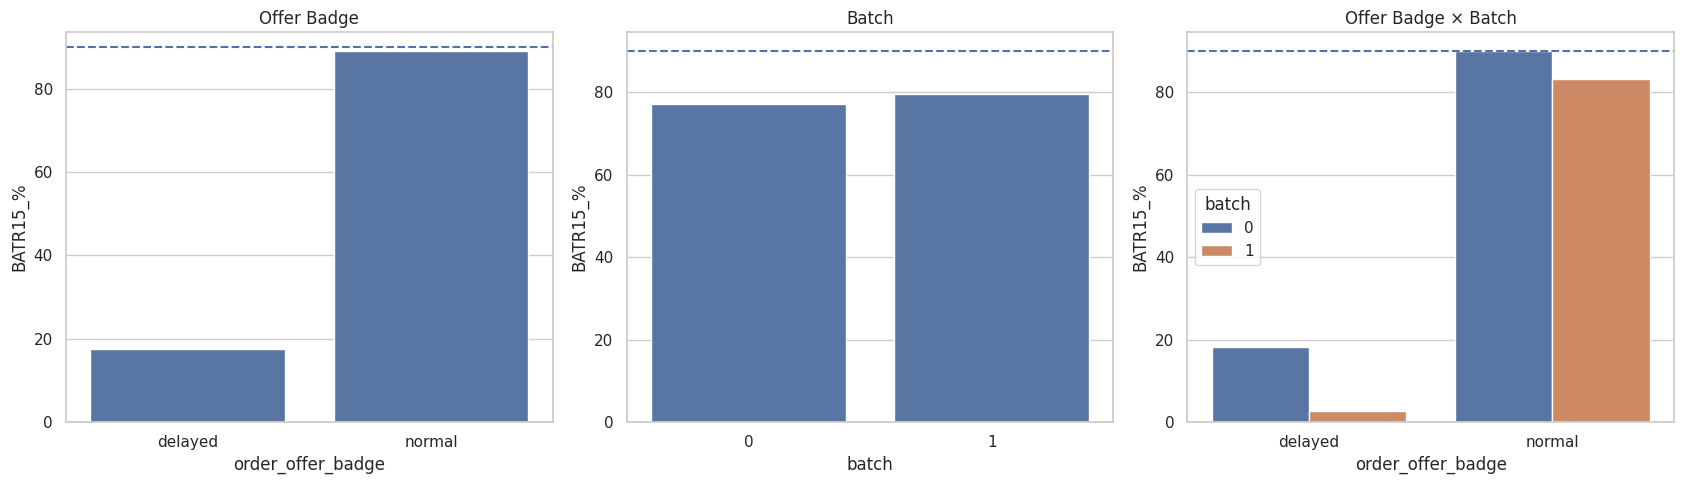

In [19]:
fig, axes=plt.subplots(1,3,figsize=(17,5))
sns.barplot(data=badge, x='order_offer_badge', y='BATR15_%', ax=axes[0], color='C0'); axes[0].axhline(90,ls='--'); axes[0].set_title('Offer Badge')
sns.barplot(data=batch, x='batch', y='BATR15_%', ax=axes[1], color='C0'); axes[1].axhline(90,ls='--'); axes[1].set_title('Batch')
sns.barplot(data=badge_batch, x='order_offer_badge', y='BATR15_%', hue='batch', ax=axes[2]); axes[2].axhline(90,ls='--'); axes[2].set_title('Offer Badge × Batch')
plt.tight_layout(); plt.show()


,distance_bin,Orders,BATR15_%,P90_BATR,Late_Orders,Late_Share_%,Avg_Accept_Delay,Avg_Arrival_After_Accept
0,<0.5 km,4511,87.098,18.000,582.000,1.703,2.759,4.651
1,0.5–1 km,13217,85.261,19.000,"1,948.000",5.700,3.341,3.931
2,1–1.5 km,19475,82.573,20.000,"3,394.000",9.930,3.685,4.337
3,1.5–2 km,21052,79.950,22.000,"4,221.000",12.350,4.157,4.702
4,2–3 km,33439,76.342,23.000,"7,911.000",23.146,4.788,5.781
5,3–4 km,24011,73.541,24.000,"6,353.000",18.588,5.115,5.879
6,4–5 km,13871,74.371,23.000,"3,555.000",10.401,4.849,7.385
7,5–7 km,11220,74.269,24.000,"2,887.000",8.447,4.566,7.545
8,7–10 km,7471,72.092,27.000,"2,085.000",6.100,4.719,11.745
9,10+ km,3315,62.534,32.000,"1,242.000",3.634,7.071,8.518


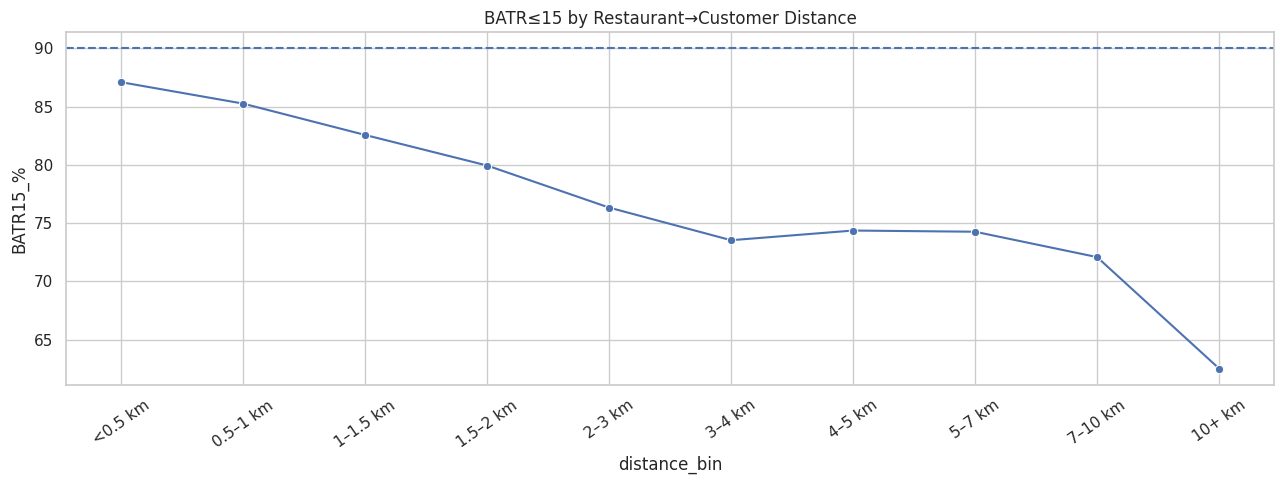

In [20]:
distance = performance_table('distance_bin').sort_values('distance_bin')
display(distance[['distance_bin','Orders','BATR15_%','P90_BATR','Late_Orders','Late_Share_%','Avg_Accept_Delay','Avg_Arrival_After_Accept']])
fig, ax=plt.subplots(figsize=(13,5))
sns.lineplot(data=distance, x='distance_bin', y='BATR15_%', marker='o', ax=ax, color='C0')
ax.axhline(90,ls='--'); ax.tick_params(axis='x',rotation=35); ax.set_title('BATR≤15 by Restaurant→Customer Distance')
plt.tight_layout(); plt.show()


,fare_decile,Orders,BATR15_%,P90_BATR,Late_Orders,Late_Share_%,Avg_Accept_Delay,Avg_Arrival_After_Accept
0,D1,15578,96.617,10.000,527.000,1.542,0.740,3.313
1,D2,16607,93.701,13.000,"1,046.000",3.060,1.524,3.523
2,D3,14687,88.997,16.000,"1,616.000",4.728,2.418,4.090
3,D4,15179,81.810,21.000,"2,761.000",8.078,4.168,4.589
4,D5,15000,77.100,23.000,"3,435.000",10.050,5.018,7.184
5,D6,13932,73.249,25.000,"3,727.000",10.905,5.701,5.294
6,D7,15824,71.790,25.000,"4,464.000",13.061,5.577,5.840
7,D8,15218,68.853,26.000,"4,740.000",13.869,5.759,8.581
8,D9,14497,68.959,26.000,"4,500.000",13.166,5.297,8.128
9,D10,15060,51.116,33.000,"7,362.000",21.540,8.828,8.749


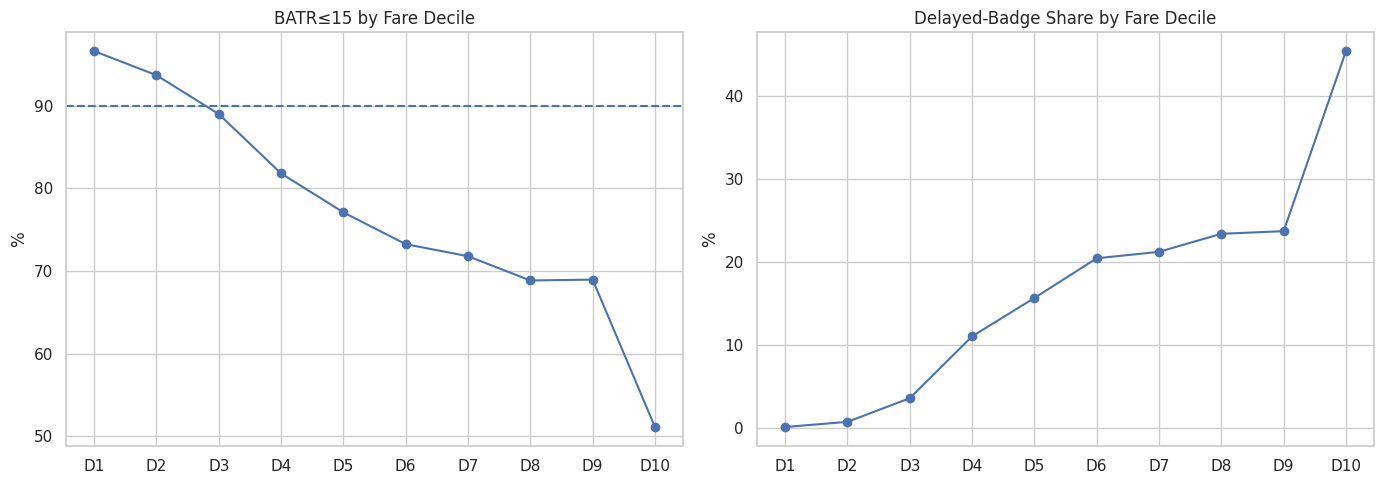

In [21]:
fare = performance_table('fare_decile').sort_values('fare_decile')
display(fare[['fare_decile','Orders','BATR15_%','P90_BATR','Late_Orders','Late_Share_%','Avg_Accept_Delay','Avg_Arrival_After_Accept']])


fare_badge = (VALID.assign(delayed_badge=(VALID.order_offer_badge=='delayed').astype(int))
              .groupby('fare_decile', observed=True)
              .agg(Orders=('order_id','size'), Rate=('BATR15','mean'), Delayed_Badge_Share=('delayed_badge','mean')).reset_index())
fig, axes=plt.subplots(1,2,figsize=(14,5))
axes[0].plot(fare_badge['fare_decile'], fare_badge['Rate']*100, marker='o'); axes[0].axhline(90,ls='--'); axes[0].set_title('BATR≤15 by Fare Decile'); axes[0].set_ylabel('%')
axes[1].plot(fare_badge['fare_decile'], fare_badge['Delayed_Badge_Share']*100, marker='o'); axes[1].set_title('Delayed-Badge Share by Fare Decile'); axes[1].set_ylabel('%')
plt.tight_layout(); plt.show()


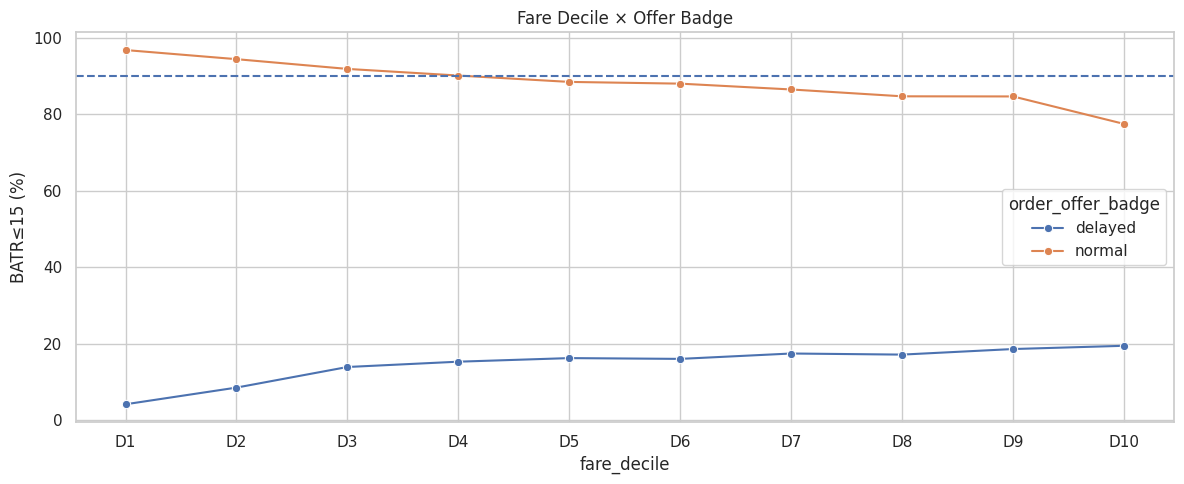

In [22]:
fb=(VALID.groupby(['fare_decile','order_offer_badge'],observed=True)
    .agg(Orders=('order_id','size'), Rate=('BATR15','mean')).reset_index())
fb=fb[fb.Orders>=20]
plt.figure(figsize=(12,5))
sns.lineplot(data=fb, x='fare_decile', y=fb['Rate']*100, hue='order_offer_badge', marker='o')
plt.axhline(90,ls='--'); plt.title('Fare Decile × Offer Badge'); plt.ylabel('BATR≤15 (%)'); plt.tight_layout(); plt.show()


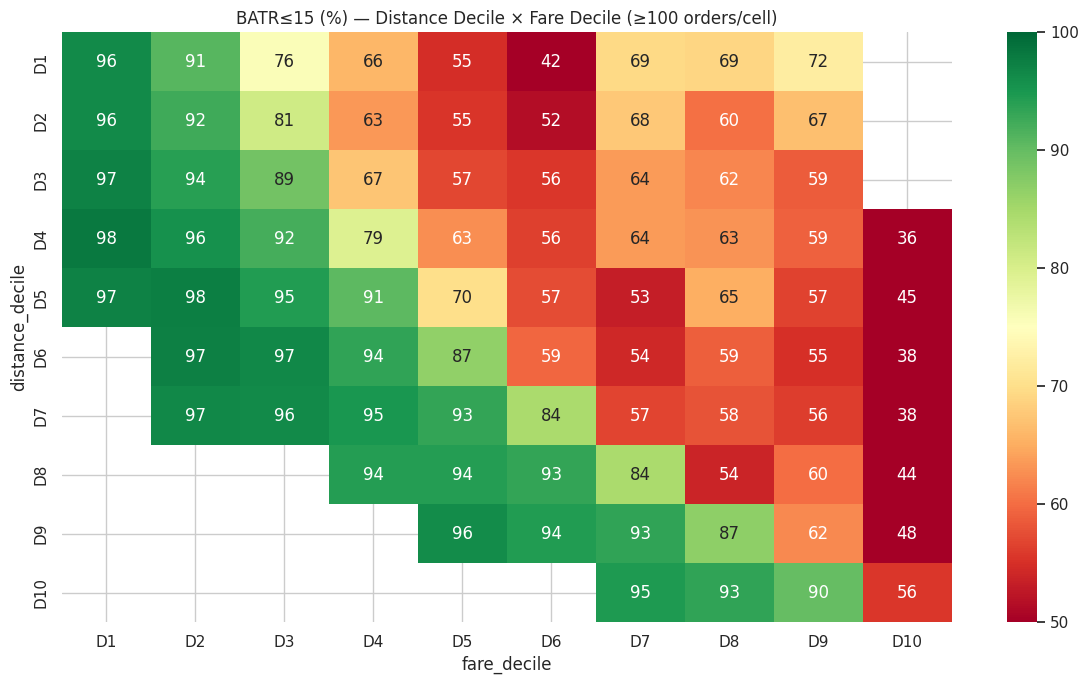

In [23]:
df2=(VALID.groupby(['distance_decile','fare_decile'],observed=True)
     .agg(Orders=('order_id','size'), Rate=('BATR15','mean')).reset_index())
df2.loc[df2.Orders<100,'Rate']=np.nan
mat=df2.pivot(index='distance_decile',columns='fare_decile',values='Rate')*100
plt.figure(figsize=(12,7)); sns.heatmap(mat,annot=True,fmt='.0f',vmin=50,vmax=100,cmap='RdYlGn')
plt.title('BATR≤15 (%) — Distance Decile × Fare Decile (≥100 orders/cell)'); plt.tight_layout(); plt.show()


Component statistics:


,count,mean,std,min,50%,75%,90%,95%,99%,max
accept_delay_min,"151,579.000",4.459,9.397,0.000,0.000,8.000,13.000,17.000,33.000,903.000
arrival_after_accept_raw_min,"151,579.000",5.072,202.104,"-69,772.000",4.000,7.000,11.000,16.000,33.000,"23,058.000"
arrival_after_accept_min,"151,579.000",5.897,93.377,0.000,4.000,7.000,11.000,16.000,33.000,"23,058.000"


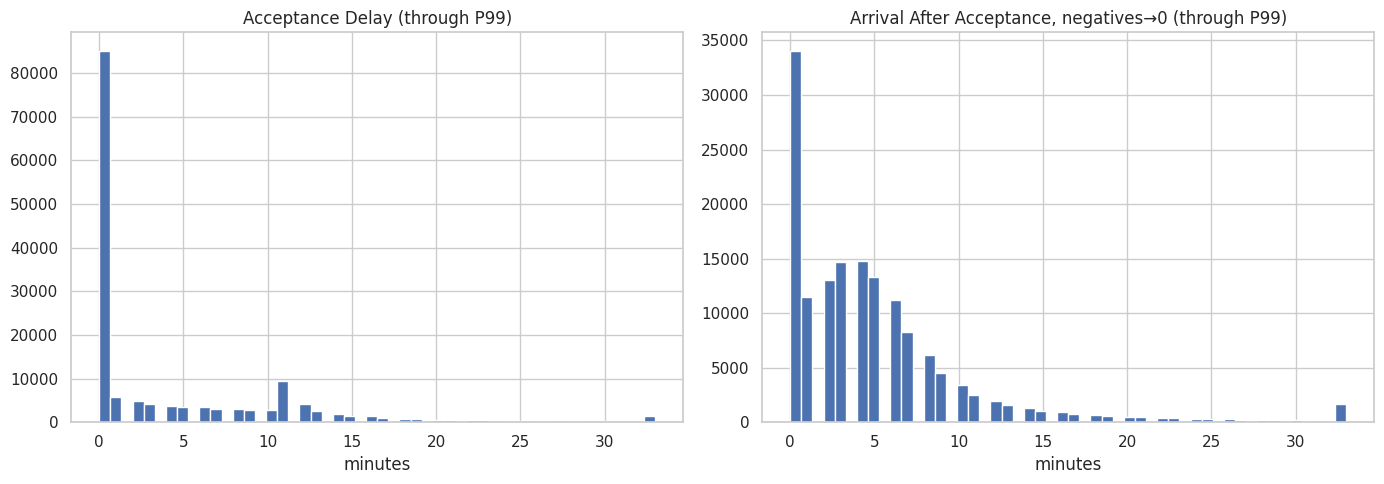

In [24]:
comp = VALID.dropna(subset=['accept_delay_min','arrival_after_accept_min']).copy()
print('Component statistics:')
display(comp[['accept_delay_min','arrival_after_accept_raw_min','arrival_after_accept_min']].describe(percentiles=[.5,.75,.9,.95,.99]).T)

cap_a=comp.accept_delay_min.quantile(.99); cap_r=comp.arrival_after_accept_min.quantile(.99)
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(comp.accept_delay_min.clip(upper=cap_a), bins=50); axes[0].set_title('Acceptance Delay (through P99)'); axes[0].set_xlabel('minutes')
axes[1].hist(comp.arrival_after_accept_min.clip(upper=cap_r), bins=50); axes[1].set_title('Arrival After Acceptance, negatives→0 (through P99)'); axes[1].set_xlabel('minutes')
plt.tight_layout(); plt.show()


,mechanism,Orders,Share_%
1,Neither alone >15; combined delay,16821,49.217
0,Acceptance alone >15,10093,29.532
2,Post-accept arrival alone >15,7263,21.251


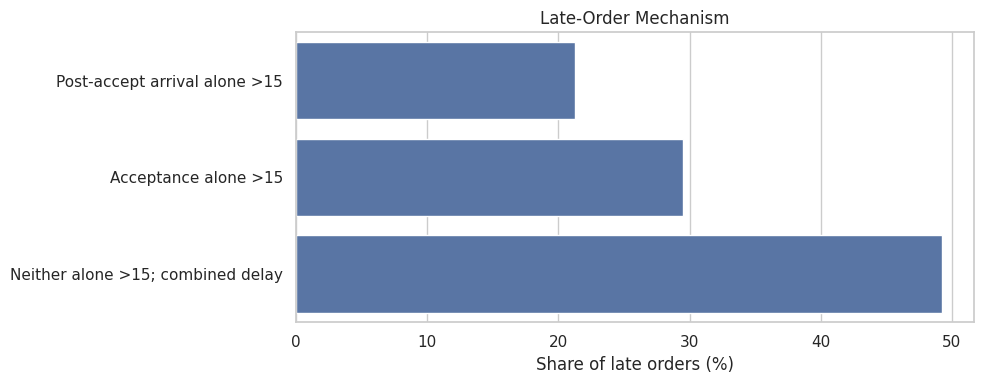

In [25]:
late = comp[comp.BATR15==0].copy()
late['mechanism'] = np.select([
    late.accept_delay_min > 15,
    (late.accept_delay_min <= 15) & (late.arrival_after_accept_min > 15),
    (late.accept_delay_min <= 15) & (late.arrival_after_accept_min <= 15)
], ['Acceptance alone >15','Post-accept arrival alone >15','Neither alone >15; combined delay'], default='Other')
mechanism=(late.groupby('mechanism').agg(Orders=('order_id','size')).reset_index())
mechanism['Share_%']=100*mechanism.Orders/mechanism.Orders.sum()
display(mechanism.sort_values('Orders',ascending=False))
plt.figure(figsize=(10,4)); sns.barplot(data=mechanism.sort_values('Share_%'),y='mechanism',x='Share_%', color='C0'); plt.title('Late-Order Mechanism'); plt.xlabel('Share of late orders (%)'); plt.ylabel(''); plt.tight_layout(); plt.show()


,accept_threshold,arrival_threshold,Share_meeting_both_%,Accept_within_%,Arrival_within_%
0,1,14,57.055,59.968,93.814
1,2,13,59.684,63.153,92.983
2,3,12,61.798,65.941,91.943
3,4,11,63.318,68.351,90.631
4,5,10,64.543,70.661,88.995
5,6,9,65.269,72.899,86.772
6,7,8,65.206,74.882,83.795
7,8,7,64.270,76.836,79.744
8,9,6,61.944,78.640,74.283
9,10,5,57.879,80.448,66.891


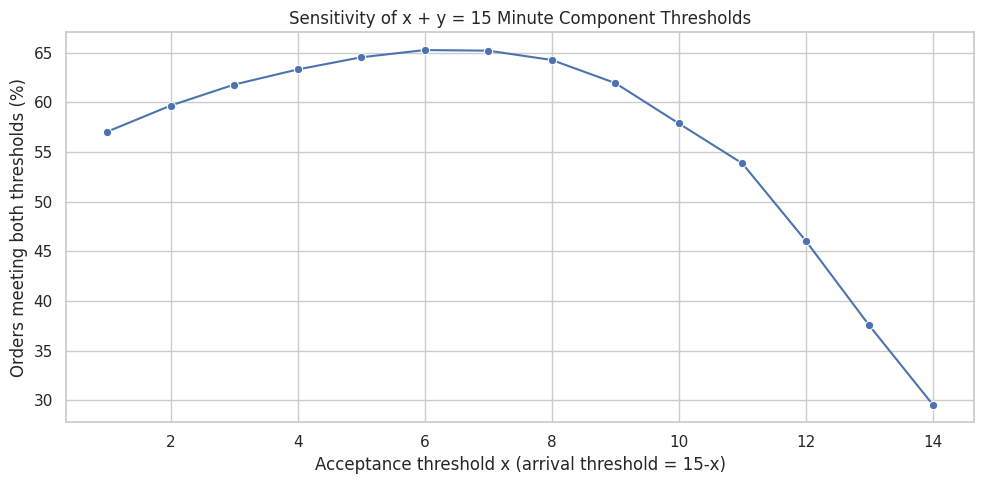

In [26]:
frontier=[]
for x_thr in range(1,15):
    y_thr=15-x_thr
    ok=(comp.accept_delay_min<=x_thr) & (comp.arrival_after_accept_min<=y_thr)
    frontier.append({'accept_threshold':x_thr,'arrival_threshold':y_thr,'Share_meeting_both_%':100*ok.mean(),
                     'Accept_within_%':100*(comp.accept_delay_min<=x_thr).mean(),'Arrival_within_%':100*(comp.arrival_after_accept_min<=y_thr).mean()})
frontier=pd.DataFrame(frontier)
display(frontier)
plt.figure(figsize=(10,5)); sns.lineplot(data=frontier,x='accept_threshold',y='Share_meeting_both_%',marker='o', color='C0'); plt.title('Sensitivity of x + y = 15 Minute Component Thresholds'); plt.xlabel('Acceptance threshold x (arrival threshold = 15-x)'); plt.ylabel('Orders meeting both thresholds (%)'); plt.tight_layout(); plt.show()


In [27]:
comp_group=(comp.groupby('BATR15').agg(Orders=('order_id','size'),Median_Accept=('accept_delay_min','median'),P90_Accept=('accept_delay_min',q90),Median_Arrival=('arrival_after_accept_min','median'),P90_Arrival=('arrival_after_accept_min',q90)).reset_index())
comp_group['Group']=comp_group.BATR15.map({1:'Within 15',0:'Late >15'})
display(comp_group[['Group','Orders','Median_Accept','P90_Accept','Median_Arrival','P90_Arrival']])


,Group,Orders,Median_Accept,P90_Accept,Median_Arrival,P90_Arrival
0,Late >15,34177,12.000,25.000,8.000,24.000
1,Within 15,117402,0.000,7.000,3.000,8.000


,Utilization_Quintile,Cells,Avg_Orders,Avg_OPB,BATR15,P90,BATR15_%
0,Q1 low,829,12.677,1.000,0.739,19.400,73.882
1,Q2,829,18.413,1.068,0.731,19.900,73.091
2,Q3,828,15.202,1.107,0.770,18.000,76.954
3,Q4,829,18.557,1.179,0.765,19.000,76.534
4,Q5 high,829,15.105,1.336,0.801,17.000,80.127


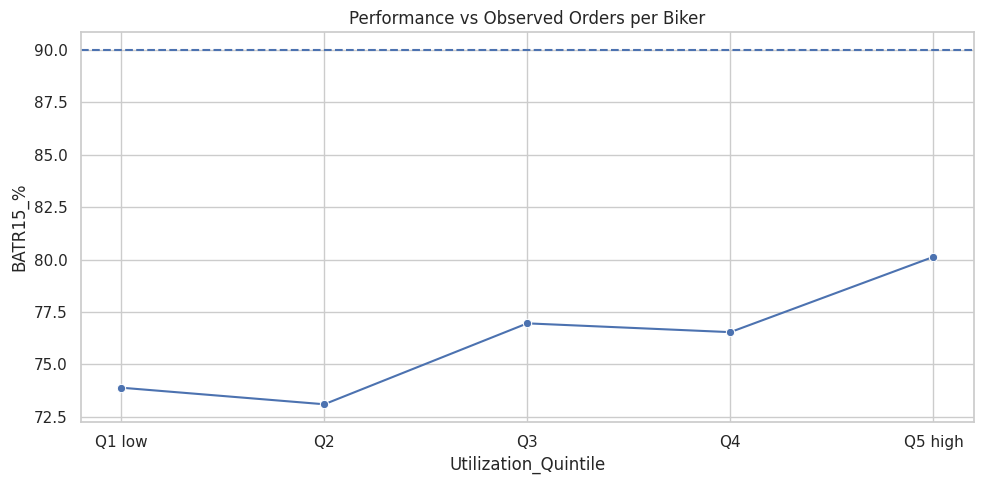

In [28]:
market = (VALID.groupby(['slot_date','order_city','district','slot_hour'],observed=True)
          .agg(Orders=('order_id','size'), Active_Bikers_Observed=('biker','nunique'), BATR15_Rate=('BATR15','mean'), P90_BATR=('BATR_min',q90), Late_Orders=('Late15','sum')).reset_index())
market['Orders_per_Observed_Biker'] = market['Orders']/market['Active_Bikers_Observed'].replace(0,np.nan)

m=market[market.Orders>=10].copy()
m['Volume_Quintile']=pd.qcut(m.Orders.rank(method='first'),5,labels=['Q1 low','Q2','Q3','Q4','Q5 high'])
m['Utilization_Quintile']=pd.qcut(m.Orders_per_Observed_Biker.rank(method='first'),5,labels=['Q1 low','Q2','Q3','Q4','Q5 high'])
util=(m.groupby('Utilization_Quintile',observed=True).agg(Cells=('Orders','size'),Avg_Orders=('Orders','mean'),Avg_OPB=('Orders_per_Observed_Biker','mean'),BATR15=('BATR15_Rate','mean'),P90=('P90_BATR','median')).reset_index())
util['BATR15_%']=100*util.BATR15
display(util)
plt.figure(figsize=(10,5)); sns.lineplot(data=util,x='Utilization_Quintile',y='BATR15_%',marker='o', color='C0'); plt.axhline(90,ls='--'); plt.title('Performance vs Observed Orders per Biker'); plt.tight_layout(); plt.show()


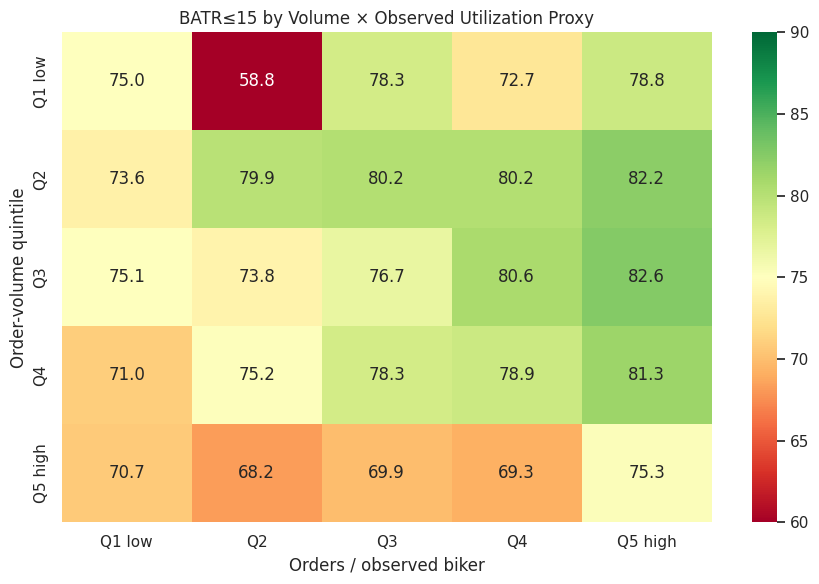

In [29]:
uv=(m.groupby(['Volume_Quintile','Utilization_Quintile'],observed=True).agg(Cells=('Orders','size'),Rate=('BATR15_Rate','mean')).reset_index())
mat=uv.pivot(index='Volume_Quintile',columns='Utilization_Quintile',values='Rate')*100
plt.figure(figsize=(9,6)); sns.heatmap(mat,annot=True,fmt='.1f',vmin=60,vmax=90,cmap='RdYlGn')
plt.title('BATR≤15 by Volume × Observed Utilization Proxy'); plt.xlabel('Orders / observed biker'); plt.ylabel('Order-volume quintile'); plt.tight_layout(); plt.show()


In [30]:
ctx_cols=['district','slot_hour','order_offer_badge']
ctx=(VALID.groupby(ctx_cols,dropna=False,observed=True).agg(N=('order_id','size'),S=('BATR15','sum')).reset_index())
PRIOR_N=50
ctx['Expected_Rate']=(ctx.S + PRIOR_N*OVERALL)/(ctx.N+PRIOR_N)
entity_base=VALID.merge(ctx[ctx_cols+['Expected_Rate']],on=ctx_cols,how='left')
entity_base['Expected_Late']=1-entity_base['Expected_Rate']

def entity_table(entity, min_orders):
    e=(entity_base.groupby(entity,dropna=False)
       .agg(Orders=('order_id','size'),Successes=('BATR15','sum'),Observed_Rate=('BATR15','mean'),Expected_Rate=('Expected_Rate','mean'),Late_Orders=('Late15','sum'),Expected_Late_Orders=('Expected_Late','sum'),Median_BATR=('BATR_min','median'),P90_BATR=('BATR_min',q90)).reset_index())
    e=e[e.Orders>=min_orders].copy()

    e['Smoothed_Rate']=(e.Successes+PRIOR_N*OVERALL)/(e.Orders+PRIOR_N)
    e['Observed_%']=100*e.Observed_Rate; e['Expected_%']=100*e.Expected_Rate; e['Smoothed_%']=100*e.Smoothed_Rate
    e['Context_Gap_pp']=100*(e.Observed_Rate-e.Expected_Rate)
    e['Excess_Late_vs_Context']=e.Late_Orders-e.Expected_Late_Orders
    lo,hi=wilson_ci(e.Successes,e.Orders); e['CI95_Low']=100*lo; e['CI95_High']=100*hi
    return e


In [31]:
vendor = entity_table('vendor', min_orders=50)
print('Worst vendors by smoothed raw rate (≥50 orders):')
display(vendor.nsmallest(20,'Smoothed_%')[['vendor','Orders','Observed_%','Smoothed_%','CI95_Low','CI95_High','Expected_%','Context_Gap_pp','Excess_Late_vs_Context','P90_BATR']])
print('\nVendors creating the most excess late orders vs operational context:')
display(vendor.nlargest(20,'Excess_Late_vs_Context')[['vendor','Orders','Observed_%','Expected_%','Context_Gap_pp','Late_Orders','Expected_Late_Orders','Excess_Late_vs_Context','P90_BATR']])


Worst vendors by smoothed raw rate (≥50 orders):


,vendor,Orders,Observed_%,Smoothed_%,CI95_Low,CI95_High,Expected_%,Context_Gap_pp,Excess_Late_vs_Context,P90_BATR
917,1213971,89,40.449,53.760,30.853,50.836,61.885,-21.436,19.078,34.000
595,1082268,53,32.075,54.103,21.092,45.482,68.377,-36.302,19.240,32.800
194,721875,368,51.359,54.480,46.264,56.425,59.192,-7.833,28.825,32.300
850,1199937,161,49.068,55.794,41.458,56.722,59.352,-10.284,16.557,29.000
547,1053504,274,52.190,56.088,46.286,58.033,58.161,-5.971,16.361,31.000
152,668538,76,43.421,56.926,32.861,54.614,57.416,-13.995,10.636,33.500
249,806271,323,53.870,57.031,48.420,59.229,63.140,-9.270,29.943,30.800
102,216960,195,52.308,57.439,45.321,59.206,57.844,-5.537,10.796,27.600
1469,1317645,97,47.423,57.637,37.774,57.267,66.912,-19.489,18.905,30.000
1602,1340043,79,45.570,57.927,35.048,56.502,73.193,-27.623,21.822,37.800



Vendors creating the most excess late orders vs operational context:


,vendor,Orders,Observed_%,Expected_%,Context_Gap_pp,Late_Orders,Expected_Late_Orders,Excess_Late_vs_Context,P90_BATR
187,710289,1033,67.861,76.170,-8.309,332.000,246.164,85.836,29.000
477,1016058,1166,65.609,71.338,-5.729,401.000,334.199,66.801,30.500
156,670293,835,71.138,78.469,-7.332,241.000,179.782,61.218,26.000
1638,1345848,490,59.796,70.078,-10.282,197.000,146.617,50.383,30.000
69,186009,947,68.849,73.620,-4.771,295.000,249.822,45.178,23.400
903,1211685,776,65.851,70.979,-5.128,265.000,225.206,39.794,24.000
105,219498,900,76.667,81.007,-4.340,210.000,170.938,39.062,24.000
950,1218408,346,65.607,76.599,-10.992,119.000,80.968,38.032,27.000
355,929436,1015,64.631,68.077,-3.447,359.000,324.016,34.984,26.000
236,792459,295,70.169,81.932,-11.762,88.000,53.301,34.699,26.000


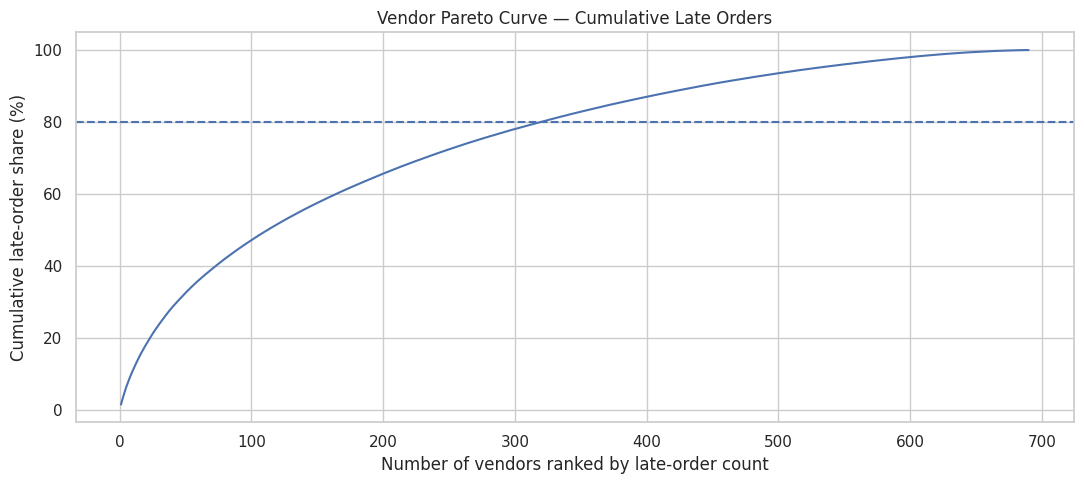

In [32]:
vp=vendor.sort_values('Late_Orders',ascending=False).copy(); vp['Cum_Late_Share_%']=100*vp.Late_Orders.cumsum()/vp.Late_Orders.sum()
fig,ax=plt.subplots(figsize=(11,5)); ax.plot(range(1,len(vp)+1),vp['Cum_Late_Share_%']); ax.axhline(80,ls='--'); ax.set(title='Vendor Pareto Curve — Cumulative Late Orders',xlabel='Number of vendors ranked by late-order count',ylabel='Cumulative late-order share (%)'); plt.tight_layout(); plt.show()


In [33]:
biker = entity_table('biker', min_orders=30)
print('Worst bikers by smoothed raw rate (≥30 orders):')
display(biker.nsmallest(20,'Smoothed_%')[['biker','Orders','Observed_%','Smoothed_%','CI95_Low','CI95_High','Expected_%','Context_Gap_pp','Excess_Late_vs_Context','P90_BATR']])
print('\nBikers creating the most excess late orders vs operational context:')
display(biker.nlargest(20,'Excess_Late_vs_Context')[['biker','Orders','Observed_%','Expected_%','Context_Gap_pp','Late_Orders','Expected_Late_Orders','Excess_Late_vs_Context','P90_BATR']])


Worst bikers by smoothed raw rate (≥30 orders):


,biker,Orders,Observed_%,Smoothed_%,CI95_Low,CI95_High,Expected_%,Context_Gap_pp,Excess_Late_vs_Context,P90_BATR
356,"3,876,370.000",150,30.000,41.863,23.241,37.758,59.302,-29.302,43.953,30.200
655,"5,054,734.000",91,34.066,49.451,25.151,44.271,48.837,-14.771,13.442,30.000
2157,"9,820,780.000",112,39.286,51.066,30.740,48.542,46.615,-7.329,8.209,33.000
1530,"9,367,590.000",66,31.818,51.488,21.849,43.788,57.113,-25.294,16.694,34.500
418,"4,161,476.000",128,42.969,52.655,34.721,51.626,49.319,-6.350,8.128,28.000
999,"6,447,588.000",105,40.952,52.727,32.028,50.516,81.659,-40.707,42.742,37.600
1438,"9,289,438.000",59,32.203,52.960,21.687,44.895,51.958,-19.755,11.655,35.000
293,"3,634,288.000",66,34.848,53.212,24.476,46.888,57.641,-22.793,15.043,34.500
564,"4,649,774.000",150,45.333,53.363,37.582,53.317,78.522,-33.189,49.783,43.000
381,"4,000,414.000",121,43.802,53.641,35.287,52.698,73.034,-29.232,35.371,39.000



Bikers creating the most excess late orders vs operational context:


,biker,Orders,Observed_%,Expected_%,Context_Gap_pp,Late_Orders,Expected_Late_Orders,Excess_Late_vs_Context,P90_BATR
564,"4,649,774.000",150,45.333,78.522,-33.189,82.000,32.217,49.783,43.000
3596,"11,222,860.000",338,69.822,83.271,-13.448,102.000,56.544,45.456,24.300
356,"3,876,370.000",150,30.000,59.302,-29.302,105.000,61.047,43.953,30.200
999,"6,447,588.000",105,40.952,81.659,-40.707,62.000,19.258,42.742,37.600
3648,"11,248,776.000",144,50.694,79.602,-28.908,71.000,29.373,41.627,36.700
1674,"9,496,246.000",236,62.712,80.054,-17.342,88.000,47.072,40.928,43.500
443,"4,259,010.000",222,60.811,79.235,-18.424,87.000,46.099,40.901,25.900
778,"5,525,412.000",162,56.173,79.387,-23.214,71.000,33.393,37.607,33.900
782,"5,538,608.000",247,64.372,79.403,-15.031,88.000,50.874,37.126,25.000
1462,"9,310,458.000",215,55.349,71.976,-16.627,96.000,60.251,35.749,28.000


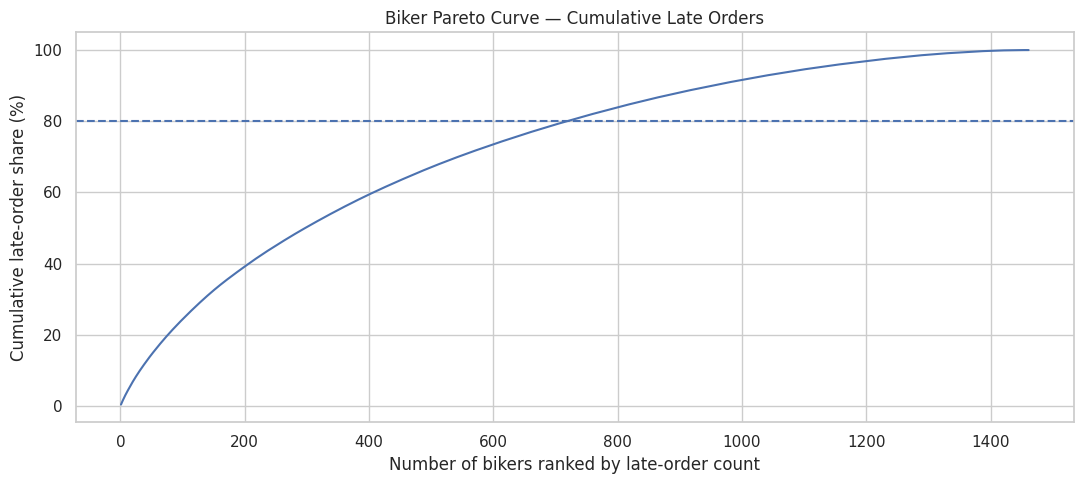

In [34]:
bp=biker.sort_values('Late_Orders',ascending=False).copy(); bp['Cum_Late_Share_%']=100*bp.Late_Orders.cumsum()/bp.Late_Orders.sum()
fig,ax=plt.subplots(figsize=(11,5)); ax.plot(range(1,len(bp)+1),bp['Cum_Late_Share_%']); ax.axhline(80,ls='--'); ax.set(title='Biker Pareto Curve — Cumulative Late Orders',xlabel='Number of bikers ranked by late-order count',ylabel='Cumulative late-order share (%)'); plt.tight_layout(); plt.show()


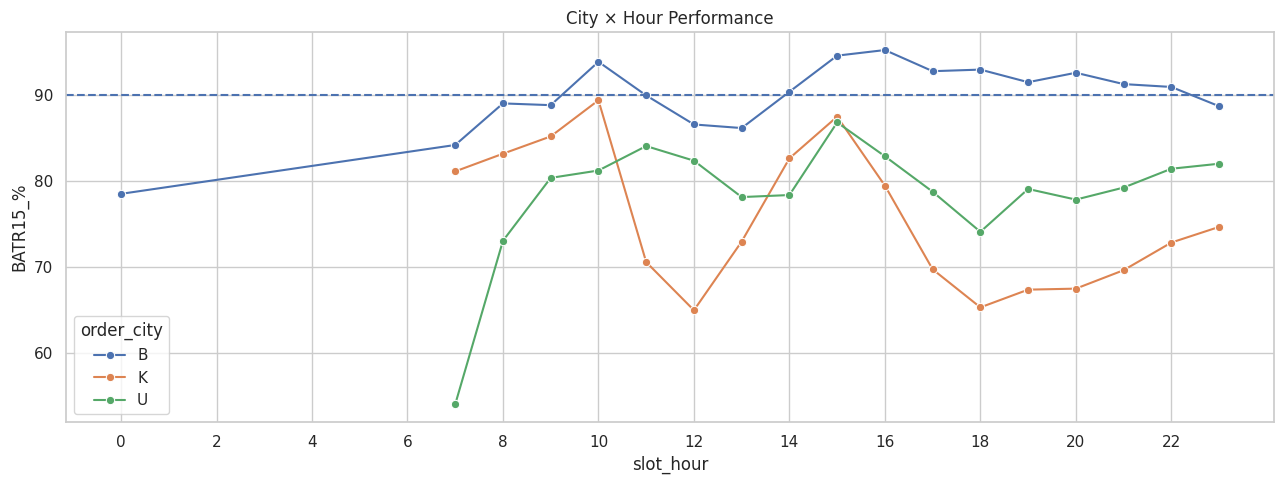

In [35]:
ch=performance_table(['order_city','slot_hour'],min_orders=50)
plt.figure(figsize=(13,5)); sns.lineplot(data=ch,x='slot_hour',y='BATR15_%',hue='order_city',marker='o'); plt.axhline(90,ls='--'); plt.title('City × Hour Performance'); plt.xticks(range(0,24,2)); plt.tight_layout(); plt.show()


In [36]:
dbadge=performance_table(['order_city','district','order_offer_badge'],min_orders=50)
print('Worst district × badge combinations:')
display(dbadge.nsmallest(25,'BATR15_%')[['order_city','district','order_offer_badge','Orders','BATR15_%','P90_BATR','Late_Orders','Avg_Accept_Delay','Avg_Arrival_After_Accept']])


Worst district × badge combinations:


,order_city,district,order_offer_badge,Orders,BATR15_%,P90_BATR,Late_Orders,Avg_Accept_Delay,Avg_Arrival_After_Accept
27,K,1520,delayed,68,5.882,44.000,64.000,13.897,11.279
39,U,1400,delayed,1006,9.145,51.500,914.000,24.628,11.684
47,U,1416,delayed,595,11.092,44.000,529.000,18.195,9.829
53,U,1428,delayed,1302,12.519,38.000,"1,139.000",16.391,8.387
41,U,1404,delayed,654,12.538,43.000,572.000,19.479,6.986
43,U,1408,delayed,436,14.450,44.000,373.000,18.319,8.124
29,K,1528,delayed,2121,14.946,38.000,"1,804.000",16.467,8.773
10,K,1476,delayed,834,15.827,37.000,702.000,16.450,8.330
14,K,1484,delayed,1468,16.144,40.000,"1,231.000",17.307,8.267
20,K,1496,delayed,345,16.232,37.000,289.000,17.304,8.568


In [37]:
impact = dh.copy()
impact['Late_Orders']=impact['Late']
impact=impact[impact.Orders>=100].sort_values('Late_Orders',ascending=False)
print('Highest-impact district-hour cells (not merely worst percentages):')
display(impact.head(25)[['order_city','district','slot_hour','Orders','Rate','P90','Late_Orders']].assign(BATR15_pct=lambda q:100*q.Rate).drop(columns='Rate'))


Highest-impact district-hour cells (not merely worst percentages):


,order_city,district,slot_hour,Orders,P90,Late_Orders,BATR15_pct
161,K,1480,20.000,2989,28.000,"1,249.000",58.213
162,K,1480,21.000,2894,26.000,"1,099.000",62.025
160,K,1480,19.000,2398,27.000,938.000,60.884
153,K,1480,12.000,2547,25.000,875.000,65.646
163,K,1480,22.000,2185,26.000,726.000,66.773
154,K,1480,13.000,2757,22.000,695.000,74.791
245,K,1512,12.000,1311,32.000,642.000,51.030
159,K,1480,18.000,1586,27.000,562.000,64.565
152,K,1480,11.000,1851,25.000,523.000,71.745
246,K,1512,13.000,1184,27.000,395.000,66.639


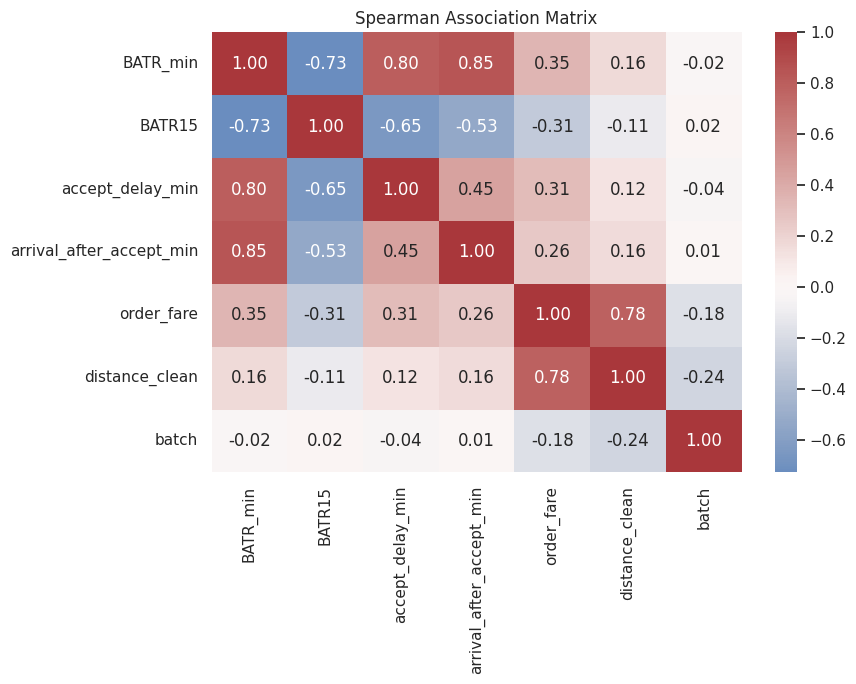

,BATR_min,BATR15,accept_delay_min,arrival_after_accept_min,order_fare,distance_clean,batch
BATR_min,1.000,-0.728,0.799,0.847,0.348,0.164,-0.017
BATR15,-0.728,1.000,-0.648,-0.526,-0.305,-0.108,0.018
accept_delay_min,0.799,-0.648,1.000,0.448,0.314,0.120,-0.039
arrival_after_accept_min,0.847,-0.526,0.448,1.000,0.255,0.157,0.010
order_fare,0.348,-0.305,0.314,0.255,1.000,0.783,-0.178
distance_clean,0.164,-0.108,0.120,0.157,0.783,1.000,-0.240
batch,-0.017,0.018,-0.039,0.010,-0.178,-0.240,1.000


In [38]:
assoc=VALID[['BATR_min','BATR15','accept_delay_min','arrival_after_accept_min','order_fare','distance_clean','batch']].corr(method='spearman')
plt.figure(figsize=(9,7)); sns.heatmap(assoc,annot=True,fmt='.2f',center=0,cmap='vlag'); plt.title('Spearman Association Matrix'); plt.tight_layout(); plt.show()
display(assoc)


In [39]:
city_t=performance_table('order_city')
dist_t=performance_table(['order_city','district']); dist_stable=dist_t[dist_t.Orders>=100]
hour_t=performance_table('slot_hour'); hour_stable=hour_t[hour_t.Orders>=500]
badge_t=performance_table('order_offer_badge')
fare_t=performance_table('fare_decile')
distance_t=performance_table('distance_bin')

worst_city=city_t.loc[city_t.BATR15_Rate.idxmin()]
worst_dist=dist_stable.loc[dist_stable.BATR15_Rate.idxmin()]
biggest_dist=dist_stable.loc[dist_stable.Late_Orders.idxmax()]
worst_hour=hour_stable.loc[hour_stable.BATR15_Rate.idxmin()]
biggest_hour=hour_stable.loc[hour_stable.Late_Orders.idxmax()]

delayed=badge_t[badge_t.order_offer_badge=='delayed']
normal=badge_t[badge_t.order_offer_badge=='normal']

print('EXECUTIVE EDA FINDINGS')
print('='*80)
print(f"1) Overall BATR≤15 = {OVERALL*100:.2f}% (target >90%); P90 BATR = {VALID.BATR_min.quantile(.90):.1f} min.")
print(f"2) Worst city = {worst_city.order_city}: {worst_city.BATR15_:.2f}%" if False else f"2) Worst city = {worst_city.order_city}: {worst_city['BATR15_%']:.2f}% and {worst_city['Late_Share_%']:.1f}% of all late orders.")
print(f"3) Highest late-order district contribution = {biggest_dist.order_city}-{int(biggest_dist.district)}: {int(biggest_dist.Late_Orders):,} late orders ({biggest_dist['Late_Share_%']:.1f}% of all failures), BATR≤15={biggest_dist['BATR15_%']:.1f}%.")
print(f"4) Worst high-volume hour = {int(worst_hour.slot_hour):02d}:00: BATR≤15={worst_hour['BATR15_%']:.1f}%, P90={worst_hour.P90_BATR:.1f} min.")
print(f"5) Largest hourly late-order contribution = {int(biggest_hour.slot_hour):02d}:00: {int(biggest_hour.Late_Orders):,} late orders ({biggest_hour['Late_Share_%']:.1f}% of all failures).")
if len(delayed) and len(normal):
    d=delayed.iloc[0]; n=normal.iloc[0]
    print(f"6) Delayed badge: BATR≤15={d['BATR15_%']:.1f}% vs normal={n['BATR15_%']:.1f}%; delayed badge accounts for {d['Late_Share_%']:.1f}% of all late orders.")
print(f"7) Distance shows a broad deterioration pattern; farthest bucket BATR≤15={distance_t.iloc[-1]['BATR15_%']:.1f}% vs shortest bucket={distance_t.iloc[0]['BATR15_%']:.1f}%.")
print(f"8) Fare association is very strong: lowest fare decile BATR≤15={fare_t.sort_values('fare_decile').iloc[0]['BATR15_%']:.1f}% vs highest decile={fare_t.sort_values('fare_decile').iloc[-1]['BATR15_%']:.1f}%. This should be interpreted jointly with distance and offer-badge mix, not as a causal fare effect.")
print('9) Vendor/biker context-adjusted tables separate entity performance from exposure to difficult district-hour-badge contexts.')
print('10) Use the district-date-hour table for operational drill-down and the high-impact district-hour table to prioritize interventions.')


EXECUTIVE EDA FINDINGS
1) Overall BATR≤15 = 77.45% (target >90%); P90 BATR = 23.0 min.
2) Worst city = K: 72.43% and 63.6% of all late orders.
3) Highest late-order district contribution = K-1480: 8,018 late orders (23.5% of all failures), BATR≤15=70.2%.
4) Worst high-volume hour = 18:00: BATR≤15=71.0%, P90=26.0 min.
5) Largest hourly late-order contribution = 20:00: 4,096 late orders (12.0% of all failures).
6) Delayed badge: BATR≤15=17.6% vs normal=89.1%; delayed badge accounts for 59.7% of all late orders.
7) Distance shows a broad deterioration pattern; farthest bucket BATR≤15=62.5% vs shortest bucket=87.1%.
8) Fare association is very strong: lowest fare decile BATR≤15=96.6% vs highest decile=51.1%. This should be interpreted jointly with distance and offer-badge mix, not as a causal fare effect.
9) Vendor/biker context-adjusted tables separate entity performance from exposure to difficult district-hour-badge contexts.
10) Use the district-date-hour table for operational drill-dow

In [40]:
evidence = pd.DataFrame([
    ['Acceptance / offer-state delay','Strong evidence','Delayed-badge orders have much lower SLA and much larger acceptance delay; late-mechanism decomposition quantifies acceptance-driven failures.','Dispatch attempts, offer history, rejection count, biker online supply, incentive history'],
    ['Geographic concentration','Strong evidence','City/district tables and district-hour heatmap show concentrated underperformance and late-order contribution.','Zone capacity, restaurant density, biker starting location, traffic, geospatial biker-to-restaurant distance'],
    ['Peak-hour supply-demand imbalance','Moderate evidence','Certain hours and high observed workload/utilization cells have lower SLA. Observed active bikers are only a proxy.','True online/available bikers, utilization state, unassigned backlog, concurrent orders'],
    ['Restaurant/customer-distance order mix','Association, not direct proof','BATR declines with restaurant→customer distance and high fare; this may affect offer attractiveness / acceptance, but distance is not biker→restaurant distance.','Biker→restaurant distance at offer, ETA, offer acceptance/rejection sequence'],
    ['Vendor-specific operational friction','Evidence after context adjustment for some vendors','Context-adjusted vendor excess-late table identifies vendors worse than their district-hour-badge exposure predicts.','Restaurant prep time, pickup wait, geofence/event accuracy, vendor congestion'],
    ['Biker-specific performance','Evidence after context adjustment for some bikers','Context-adjusted biker table identifies repeated excess lateness beyond operational context.','Biker online time, multi-order state, GPS traces, acceptance behavior, tenure'],
    ['Batching effect','Descriptive association','Batch table and badge×batch interaction quantify whether batch is associated with poorer/better BATR.','Exact batch definition, sequence within batch, route plan, number of concurrent orders'],
],columns=['Candidate cause','Evidence level from this dataset','Evidence in this notebook','Additional data needed'])
display(evidence)


,Candidate cause,Evidence level from this dataset,Evidence in this notebook,Additional data needed
0,Acceptance / offer-state delay,Strong evidence,Delayed-badge orders have much lower SLA and m...,"Dispatch attempts, offer history, rejection co..."
1,Geographic concentration,Strong evidence,City/district tables and district-hour heatmap...,"Zone capacity, restaurant density, biker start..."
2,Peak-hour supply-demand imbalance,Moderate evidence,Certain hours and high observed workload/utili...,"True online/available bikers, utilization stat..."
3,Restaurant/customer-distance order mix,"Association, not direct proof",BATR declines with restaurant→customer distanc...,"Biker→restaurant distance at offer, ETA, offer..."
4,Vendor-specific operational friction,Evidence after context adjustment for some ven...,Context-adjusted vendor excess-late table iden...,"Restaurant prep time, pickup wait, geofence/ev..."
5,Biker-specific performance,Evidence after context adjustment for some bikers,Context-adjusted biker table identifies repeat...,"Biker online time, multi-order state, GPS trac..."
6,Batching effect,Descriptive association,Batch table and badge×batch interaction quanti...,"Exact batch definition, sequence within batch,..."
